# ABSA 전체 EDA: 다이소 뷰티 리뷰 Aspect 기반 감성 분석

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 시각화 기본 설정
plt.rcParams['figure.dpi'] = 300
sns.set_palette('Set2')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Noto Sans KR'
plt.rcParams['axes.unicode_minus'] = False

print(f"폰트 설정: {plt.rcParams['font.family']}")

폰트 설정: ['Noto Sans KR']


In [62]:
DATA_PATH = '../02_processed_data/interim/v4/absa_analysis_ready.csv'
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\n결측치:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (26267, 20)

Dtypes:
review_id                   int64
product_code                int64
user_id                   float64
rating                      int64
review_date                object
is_reorder                 object
name                       object
price                     float64
brand_id                  float64
category_1                 object
category_2                 object
text                       object
aspect                     object
aspect_sentiment           object
confidence                float64
reason                     object
review_sentiment           object
review_sentiment_score    float64
evidence                   object
summary                    object
dtype: object

결측치:
user_id        270
review_date    270
is_reorder     270
price           45
brand_id        45
category_1      45
dtype: int64


## 2. 데이터 개요

In [63]:
n_reviews = df['review_id'].nunique()
n_products = df['product_code'].nunique()
avg_aspects = df.groupby('review_id')['aspect'].count().mean()

print(f"고유 리뷰 수: {n_reviews:,}")
print(f"고유 상품 수: {n_products:,}")
print(f"리뷰당 평균 Aspect 수: {avg_aspects:.2f}")
print(f"전체 행 수 (리뷰×Aspect): {len(df):,}")
# review_date: object + 결측치 → str/float 혼재 시 min/max 비교 오류 방지
date_series = pd.to_datetime(df['review_date'], errors='coerce')
valid_dates = date_series.dropna()
print(f"리뷰 기간: {valid_dates.min().strftime('%Y-%m-%d')} ~ {valid_dates.max().strftime('%Y-%m-%d')}")

고유 리뷰 수: 18,045
고유 상품 수: 834
리뷰당 평균 Aspect 수: 1.46
전체 행 수 (리뷰×Aspect): 26,267
리뷰 기간: 2024-01-05 ~ 2026-01-15


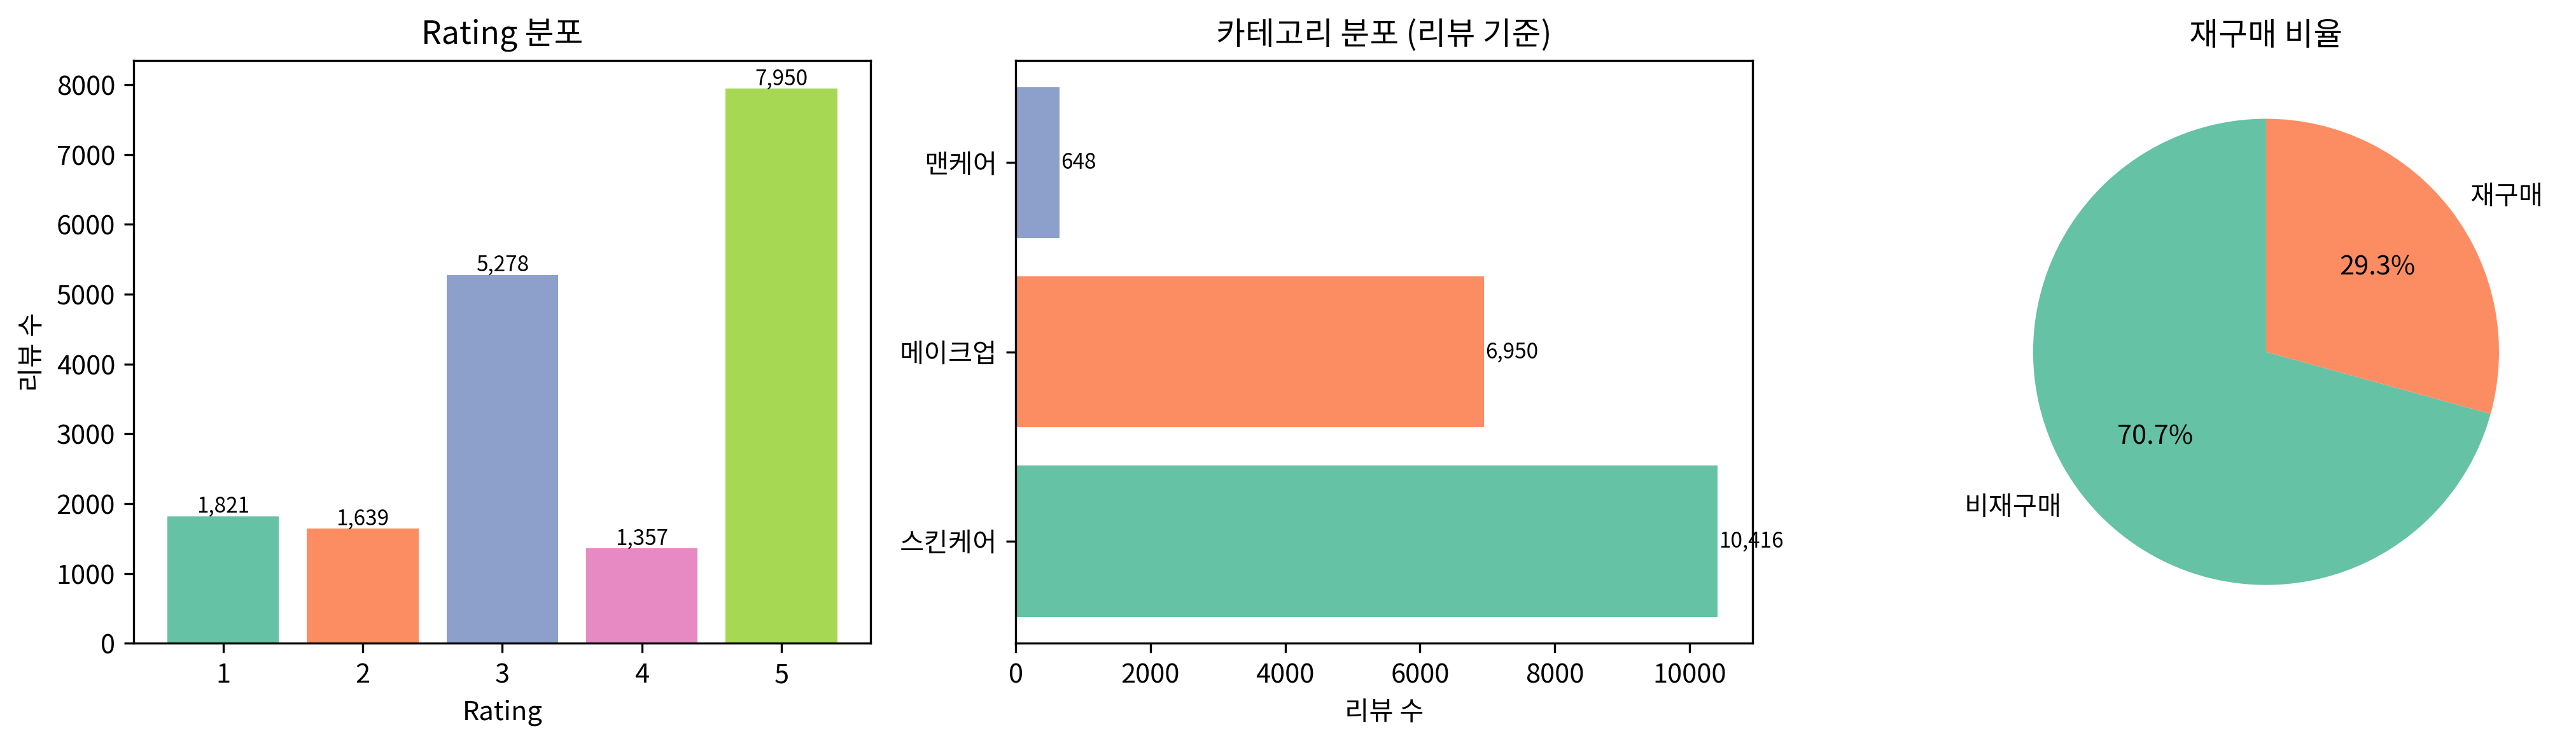

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# rating 분포
rating_counts = df.drop_duplicates('review_id')['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(int), rating_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Rating 분포')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('리뷰 수')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 50, f'{v:,}', ha='center', fontsize=8)

# category_1 분포
cat_counts = df.drop_duplicates('review_id')['category_1'].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color=sns.color_palette('Set2'))
axes[1].set_title('카테고리 분포 (리뷰 기준)')
axes[1].set_xlabel('리뷰 수')
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 20, i, f'{v:,}', va='center', fontsize=8)

# is_reorder 비율
reorder_counts = df.drop_duplicates('review_id')['is_reorder'].value_counts()
labels = ['비재구매' if x == 'False' or x is False else '재구매' for x in reorder_counts.index]
axes[2].pie(reorder_counts.values, labels=labels, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[2].set_title('재구매 비율')

plt.tight_layout()
plt.show()

## 3. Aspect별 분포 분석

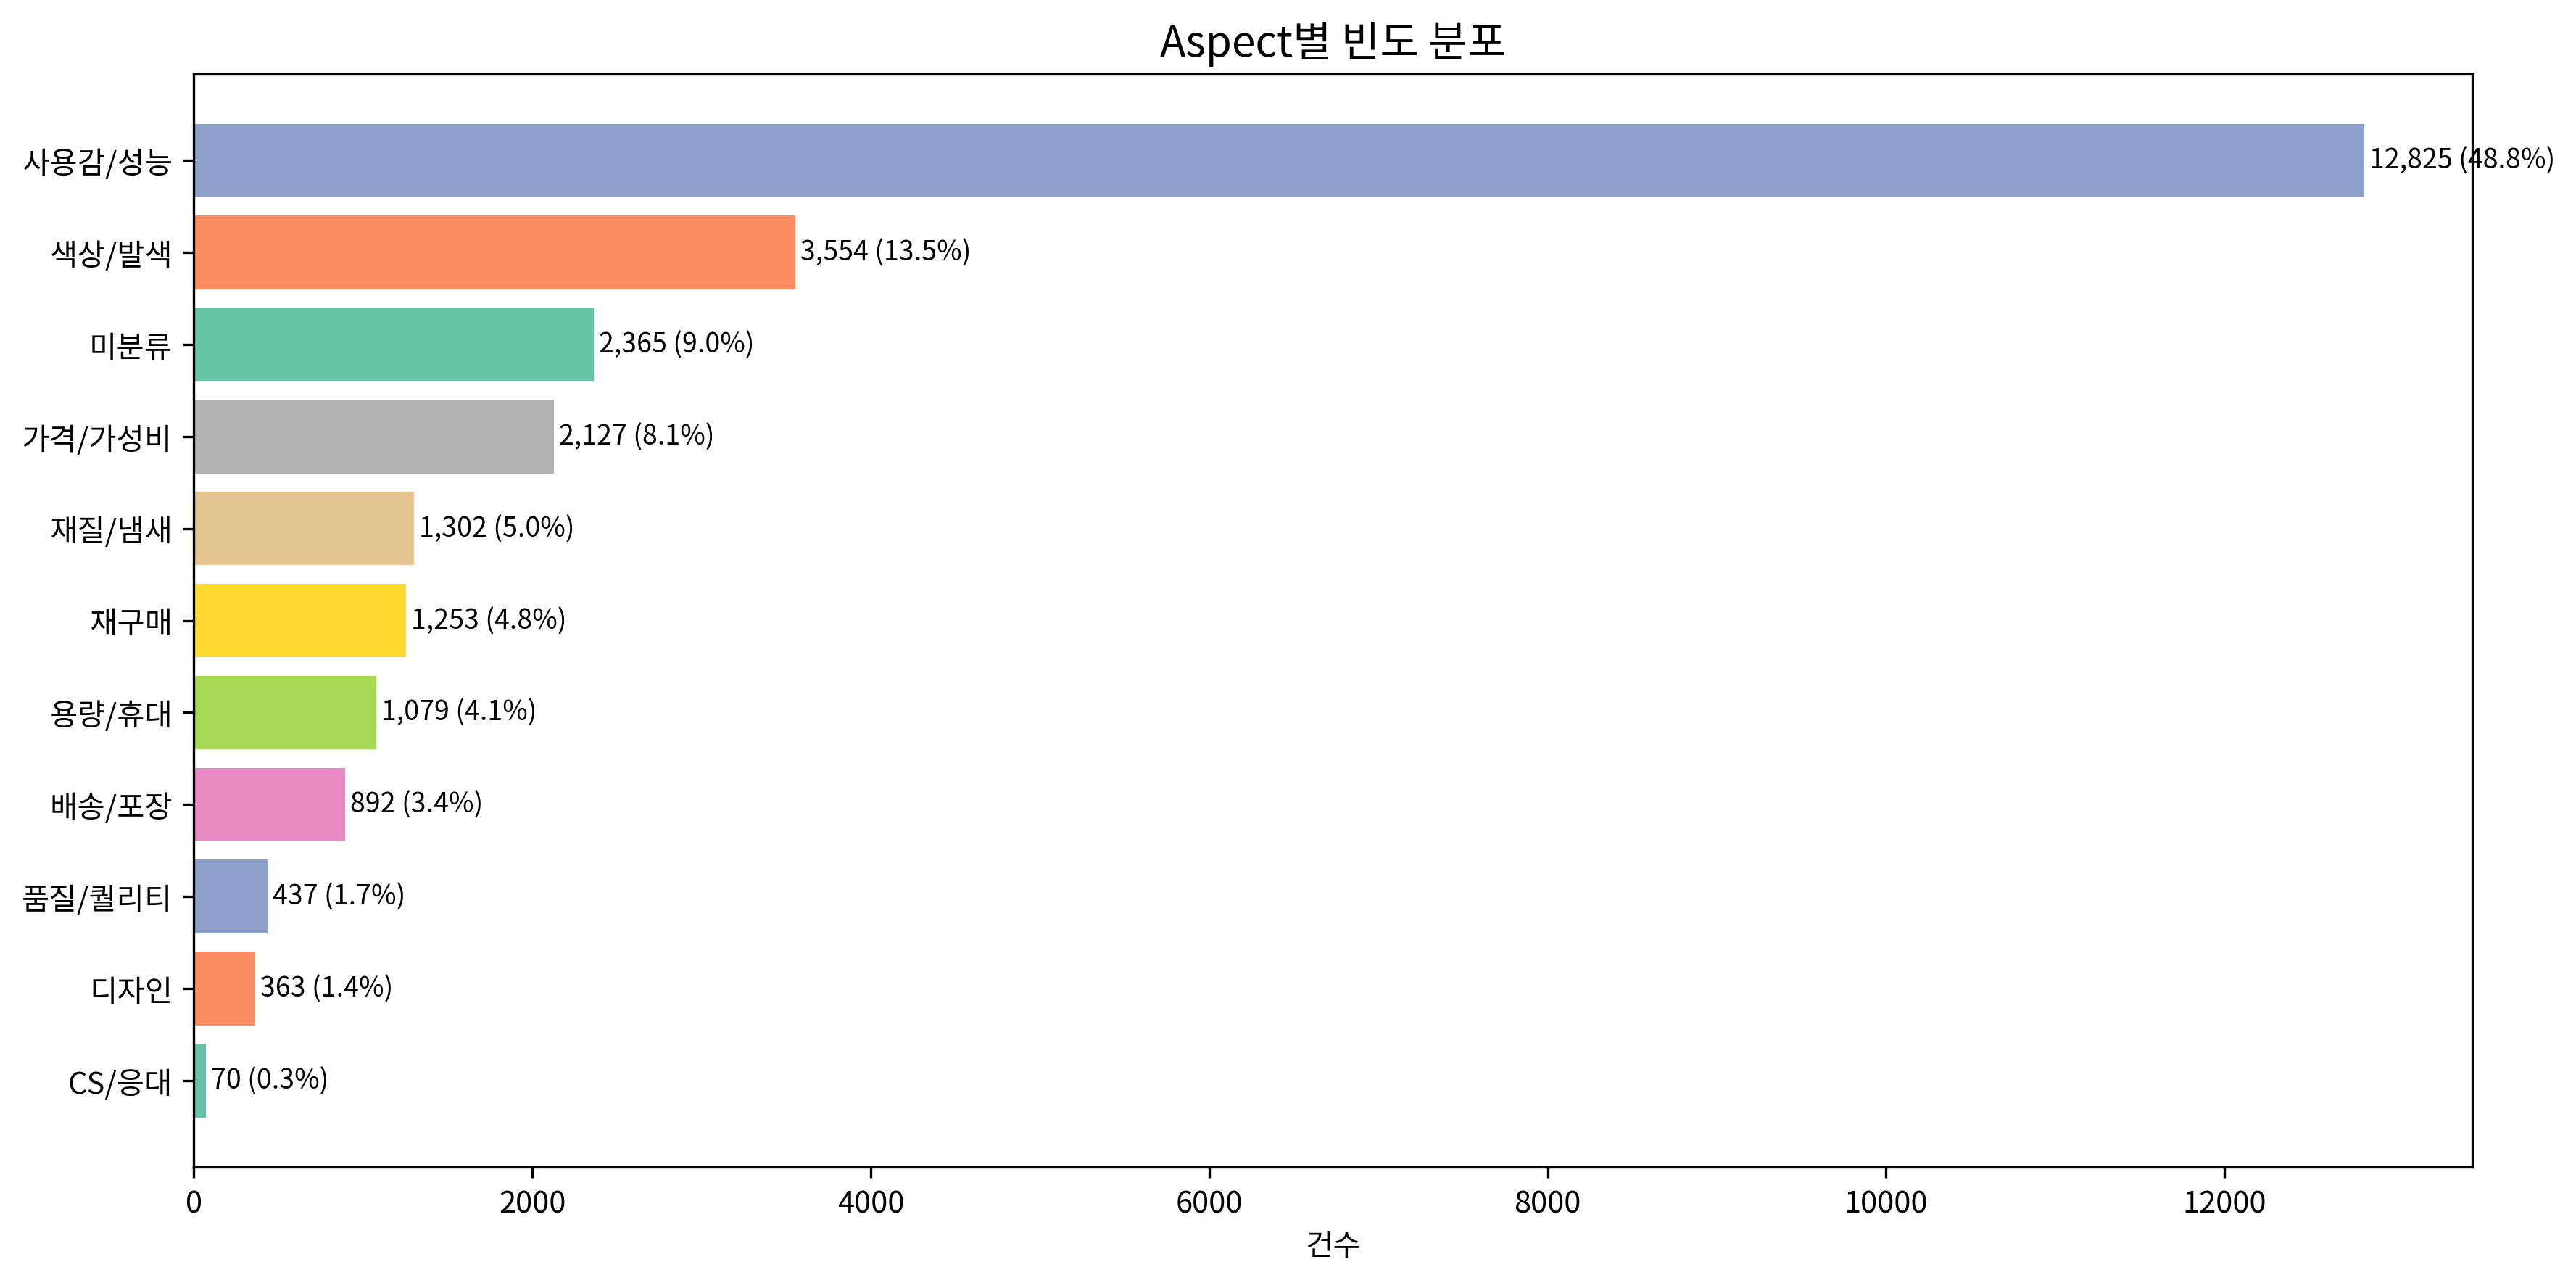


미분류 비율: 2,365건 (9.0%)


In [65]:
aspect_counts = df['aspect'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(aspect_counts.index[::-1], aspect_counts.values[::-1], color=sns.color_palette('Set2', len(aspect_counts)))
ax.set_title('Aspect별 빈도 분포', fontsize=14)
ax.set_xlabel('건수')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 30, bar.get_y() + bar.get_height()/2,
            f'{int(width):,} ({width/len(df)*100:.1f}%)',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n미분류 비율: {(df['aspect'] == '미분류').sum():,}건 ({(df['aspect'] == '미분류').mean()*100:.1f}%)")

## 4. Aspect × Sentiment 크로스 분석 (핵심)

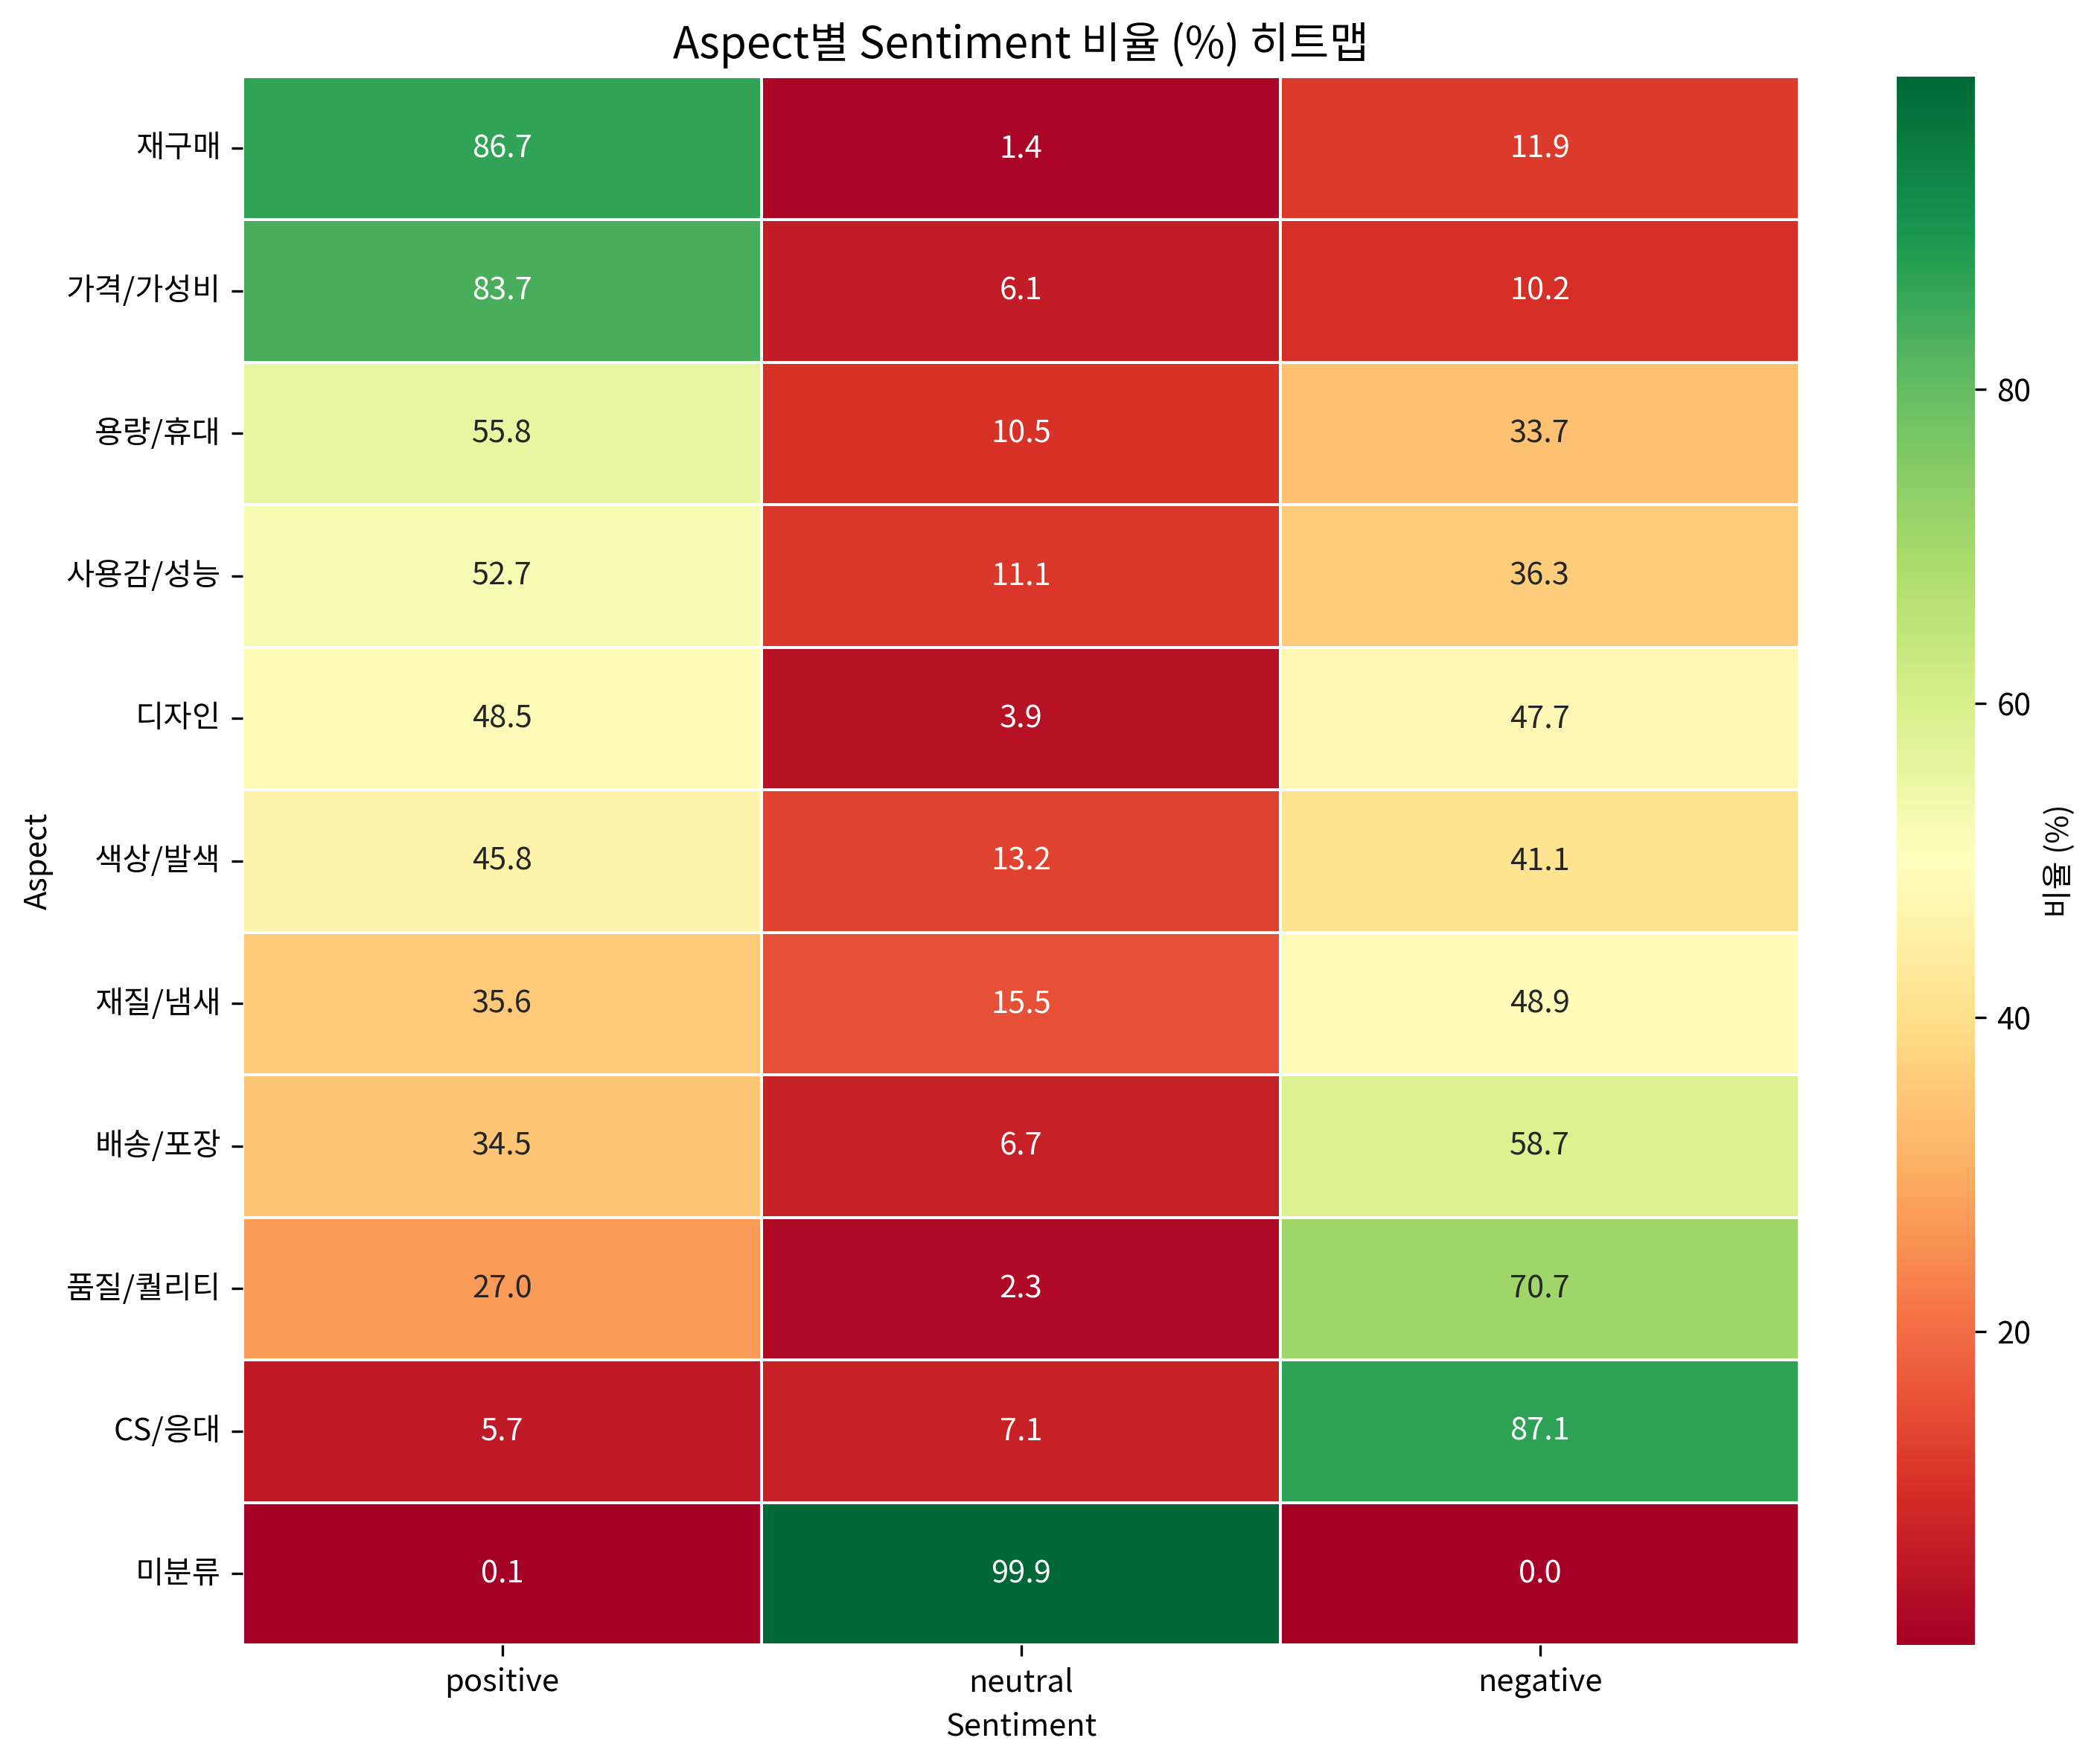

In [66]:
# 크로스탭: Aspect × Sentiment 비율
cross = pd.crosstab(df['aspect'], df['aspect_sentiment'], normalize='index') * 100
cross = cross[['positive', 'neutral', 'negative']]
cross = cross.sort_values('positive', ascending=False)

# 히트맵
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=0.5, ax=ax, cbar_kws={'label': '비율 (%)'})
ax.set_title('Aspect별 Sentiment 비율 (%) 히트맵', fontsize=14)
ax.set_ylabel('Aspect')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.show()

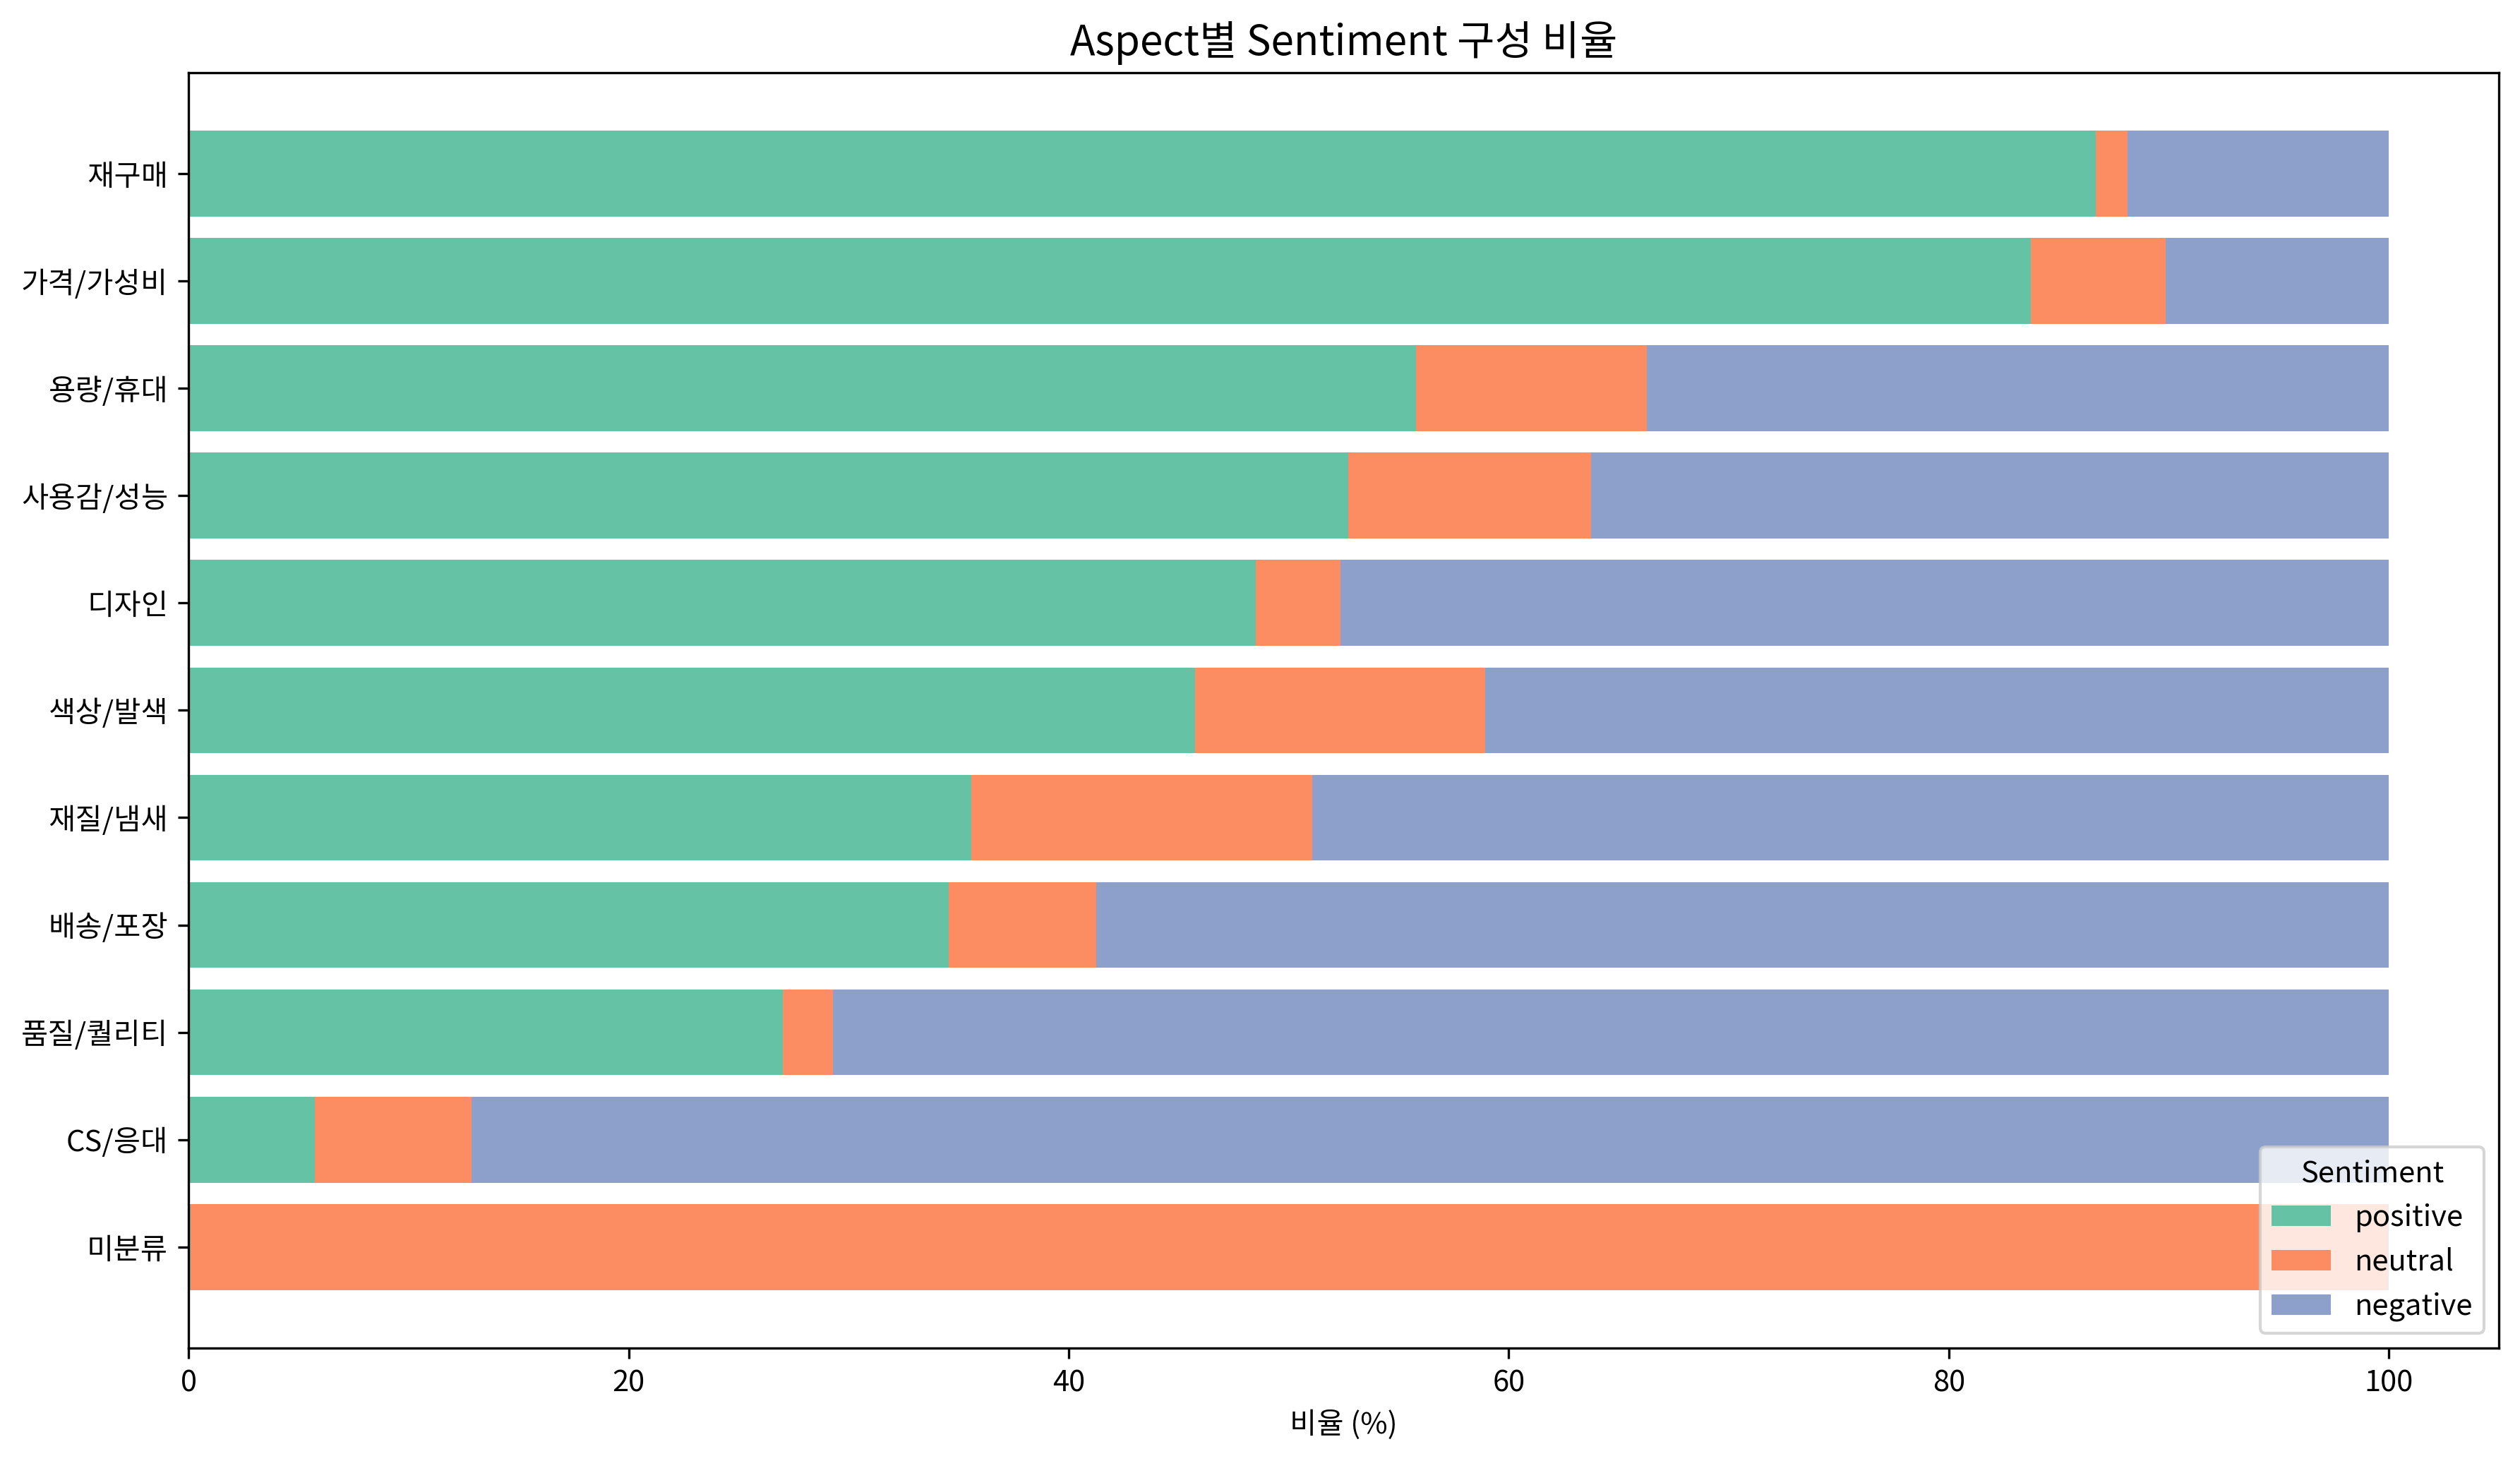

In [67]:
# 스택 막대그래프
cross_sorted = cross.sort_values('positive', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = {'positive': '#66c2a5', 'neutral': '#fc8d62', 'negative': '#8da0cb'}

left = np.zeros(len(cross_sorted))
for sentiment in ['positive', 'neutral', 'negative']:
    ax.barh(cross_sorted.index, cross_sorted[sentiment], left=left,
            label=sentiment, color=colors[sentiment])
    left += cross_sorted[sentiment].values

ax.set_title('Aspect별 Sentiment 구성 비율', fontsize=14)
ax.set_xlabel('비율 (%)')
ax.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.show()

## 5. 카테고리별 Aspect 비교

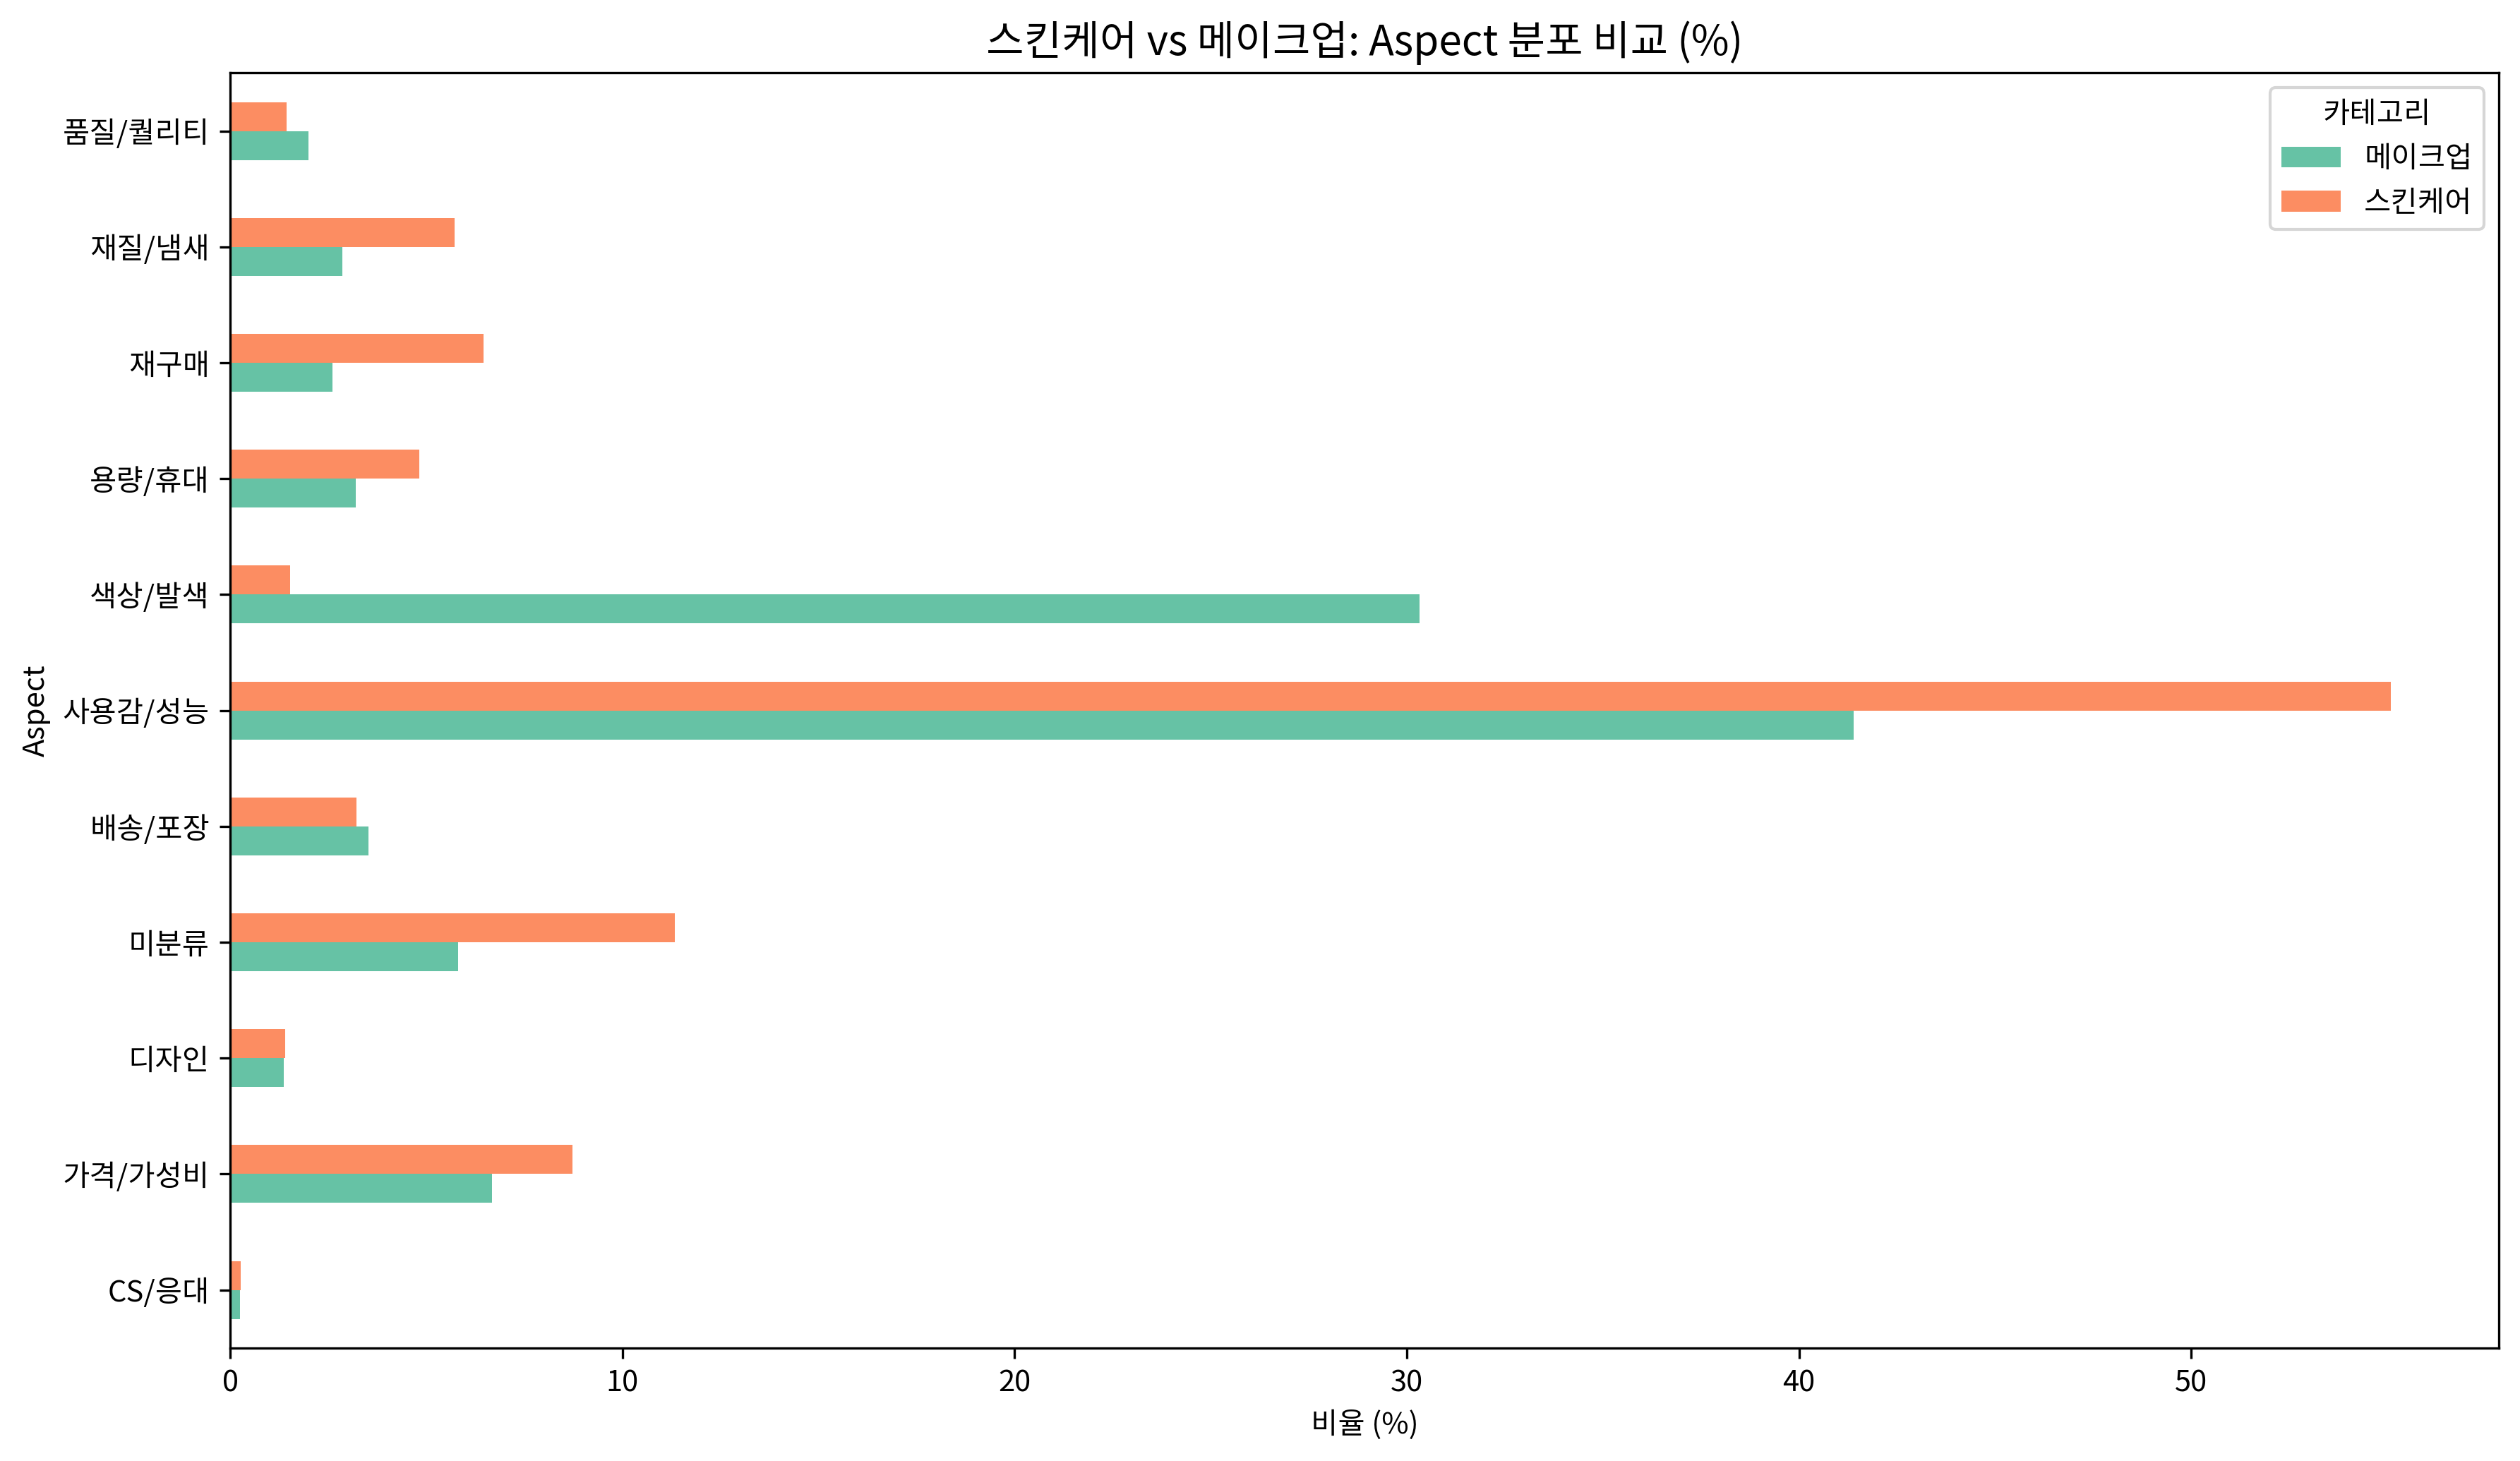

In [68]:
# 스킨케어 vs 메이크업 Aspect 분포 비교
df_cat = df[df['category_1'].isin(['스킨케어', '메이크업'])].copy()

cat_aspect = pd.crosstab(df_cat['aspect'], df_cat['category_1'], normalize='columns') * 100

fig, ax = plt.subplots(figsize=(12, 7))
cat_aspect.plot(kind='barh', ax=ax)
ax.set_title('스킨케어 vs 메이크업: Aspect 분포 비교 (%)', fontsize=14)
ax.set_xlabel('비율 (%)')
ax.set_ylabel('Aspect')
ax.legend(title='카테고리')
plt.tight_layout()
plt.show()

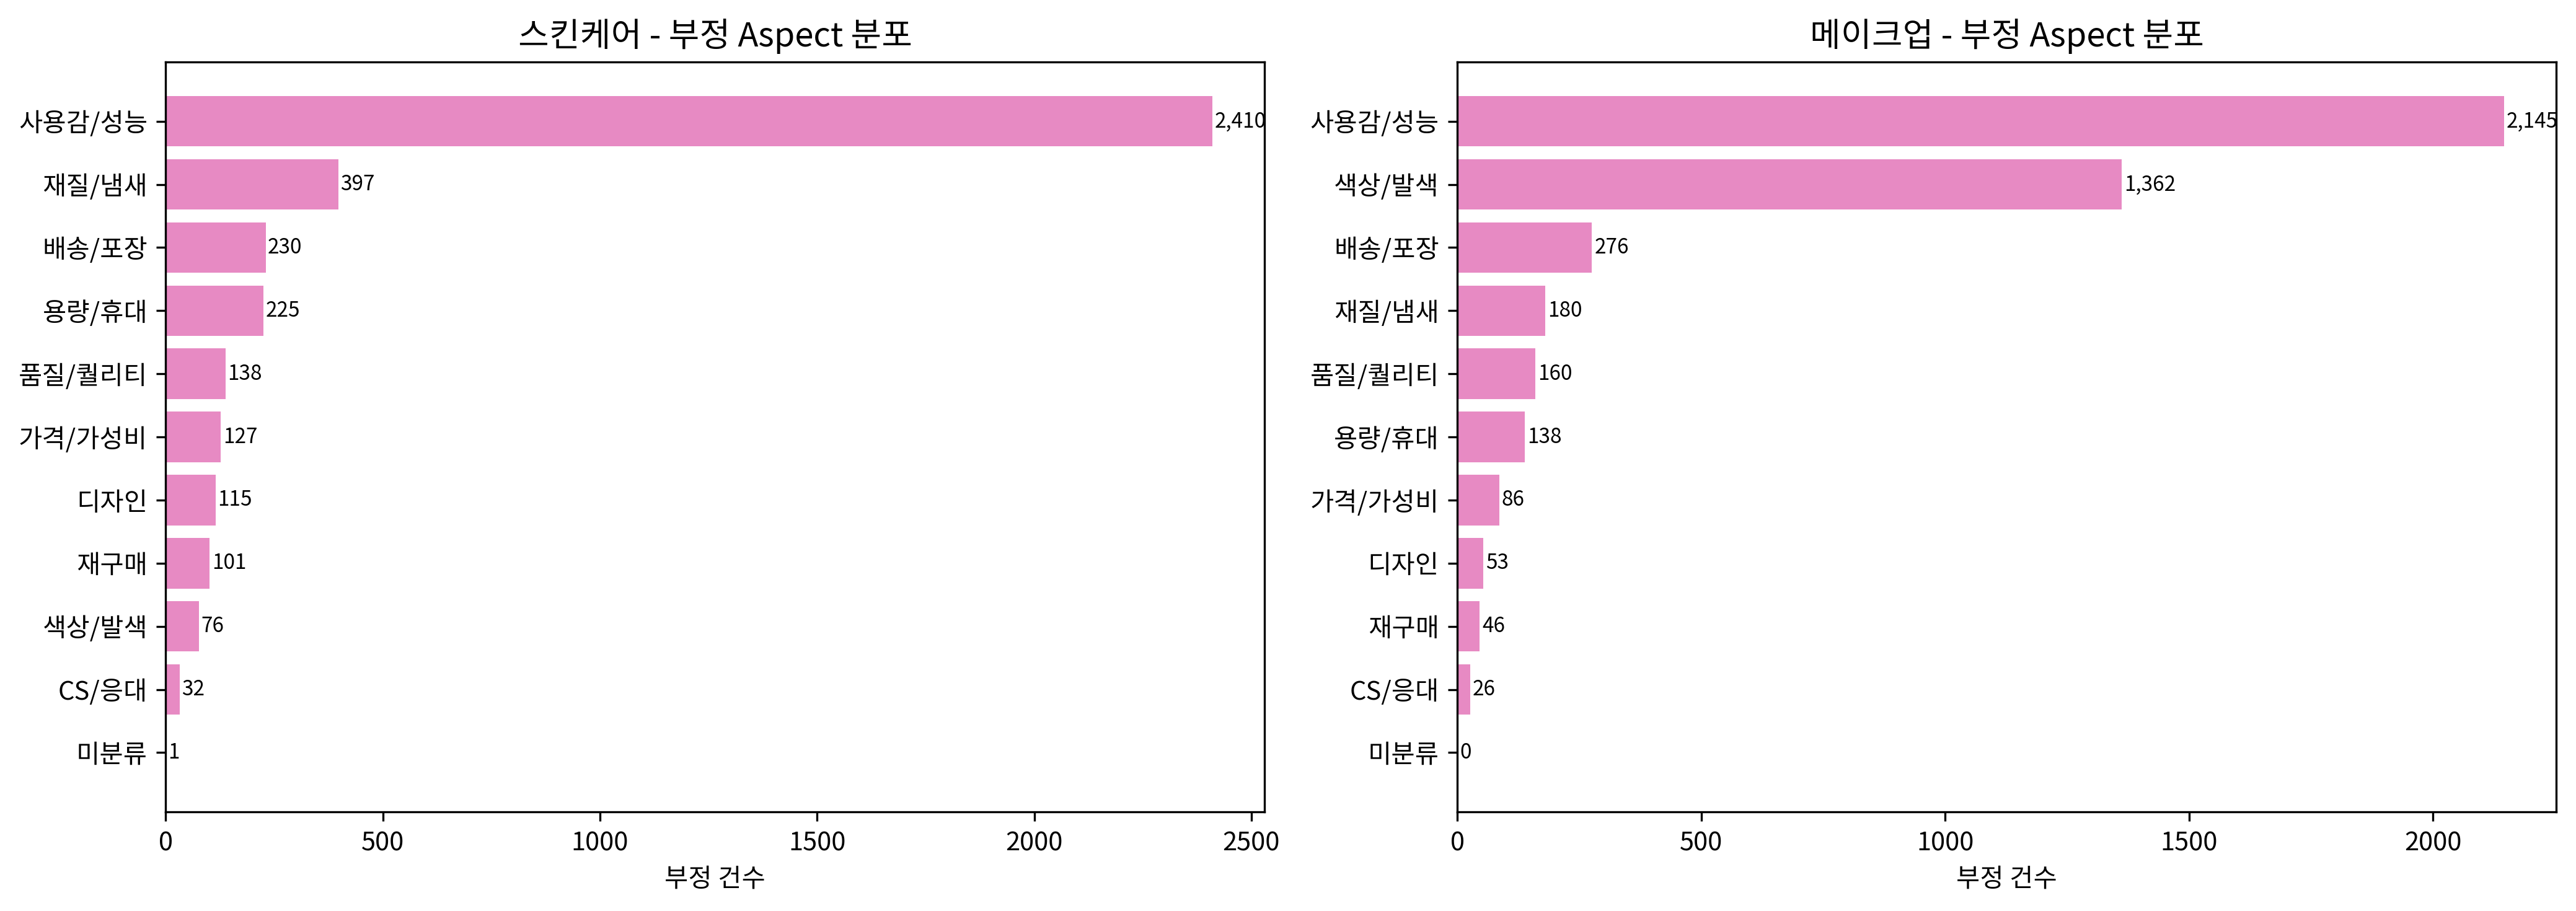

In [69]:
# 카테고리별 주요 부정 Aspect
df_neg = df_cat[df_cat['aspect_sentiment'] == 'negative']
cat_neg_aspect = pd.crosstab(df_neg['aspect'], df_neg['category_1'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cat in enumerate(['스킨케어', '메이크업']):
    data = cat_neg_aspect[cat].sort_values(ascending=True)
    axes[i].barh(data.index, data.values, color='#e78ac3')
    axes[i].set_title(f'{cat} - 부정 Aspect 분포', fontsize=13)
    axes[i].set_xlabel('부정 건수')
    for j, v in enumerate(data.values):
        axes[i].text(v + 5, j, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [70]:
# category_2(소분류)별 상위 Aspect Top 3
cat2_aspect = df.dropna(subset=['category_2']).groupby(['category_2', 'aspect']).size().reset_index(name='count')
cat2_top = cat2_aspect.sort_values(['category_2', 'count'], ascending=[True, False])
cat2_top = cat2_top.groupby('category_2').head(3)
cat2_top['rank'] = cat2_top.groupby('category_2').cumcount() + 1

print("소분류별 상위 3 Aspect:")
print("=" * 60)
for cat2 in cat2_top['category_2'].unique():
    subset = cat2_top[cat2_top['category_2'] == cat2]
    aspects = ', '.join([f"{r['aspect']}({r['count']:,})" for _, r in subset.iterrows()])
    print(f"  {cat2}: {aspects}")

소분류별 상위 3 Aspect:
  기초스킨케어: 사용감/성능(5,216), 미분류(1,107), 가격/가성비(774)
  남성메이크업: 사용감/성능(9), 미분류(3), 색상/발색(3)
  남성스킨케어: 사용감/성능(162), 가격/가성비(60), 재질/냄새(50)
  남성용면도기: 사용감/성능(100), 가격/가성비(37), 미분류(34)
  남성향수: 재질/냄새(103), 사용감/성능(42), 가격/가성비(21)
  립메이크업: 색상/발색(1,437), 사용감/성능(1,329), 재질/냄새(214)
  립케어: 사용감/성능(288), 재질/냄새(85), 색상/발색(74)
  베이스메이크업: 사용감/성능(1,498), 색상/발색(390), 가격/가성비(234)
  아이메이크업: 사용감/성능(1,163), 색상/발색(805), 가격/가성비(208)
  자외선차단제: 사용감/성능(699), 용량/휴대(116), 가격/가성비(108)
  치크/하이라이터: 색상/발색(659), 사용감/성능(505), 배송/포장(84)
  클렌징/쉐이빙: 사용감/성능(34), 가격/가성비(21), 미분류(11)
  클렌징/필링: 사용감/성능(496), 미분류(125), 가격/가성비(77)
  팩/마스크: 사용감/성능(1,284), 미분류(270), 가격/가성비(234)


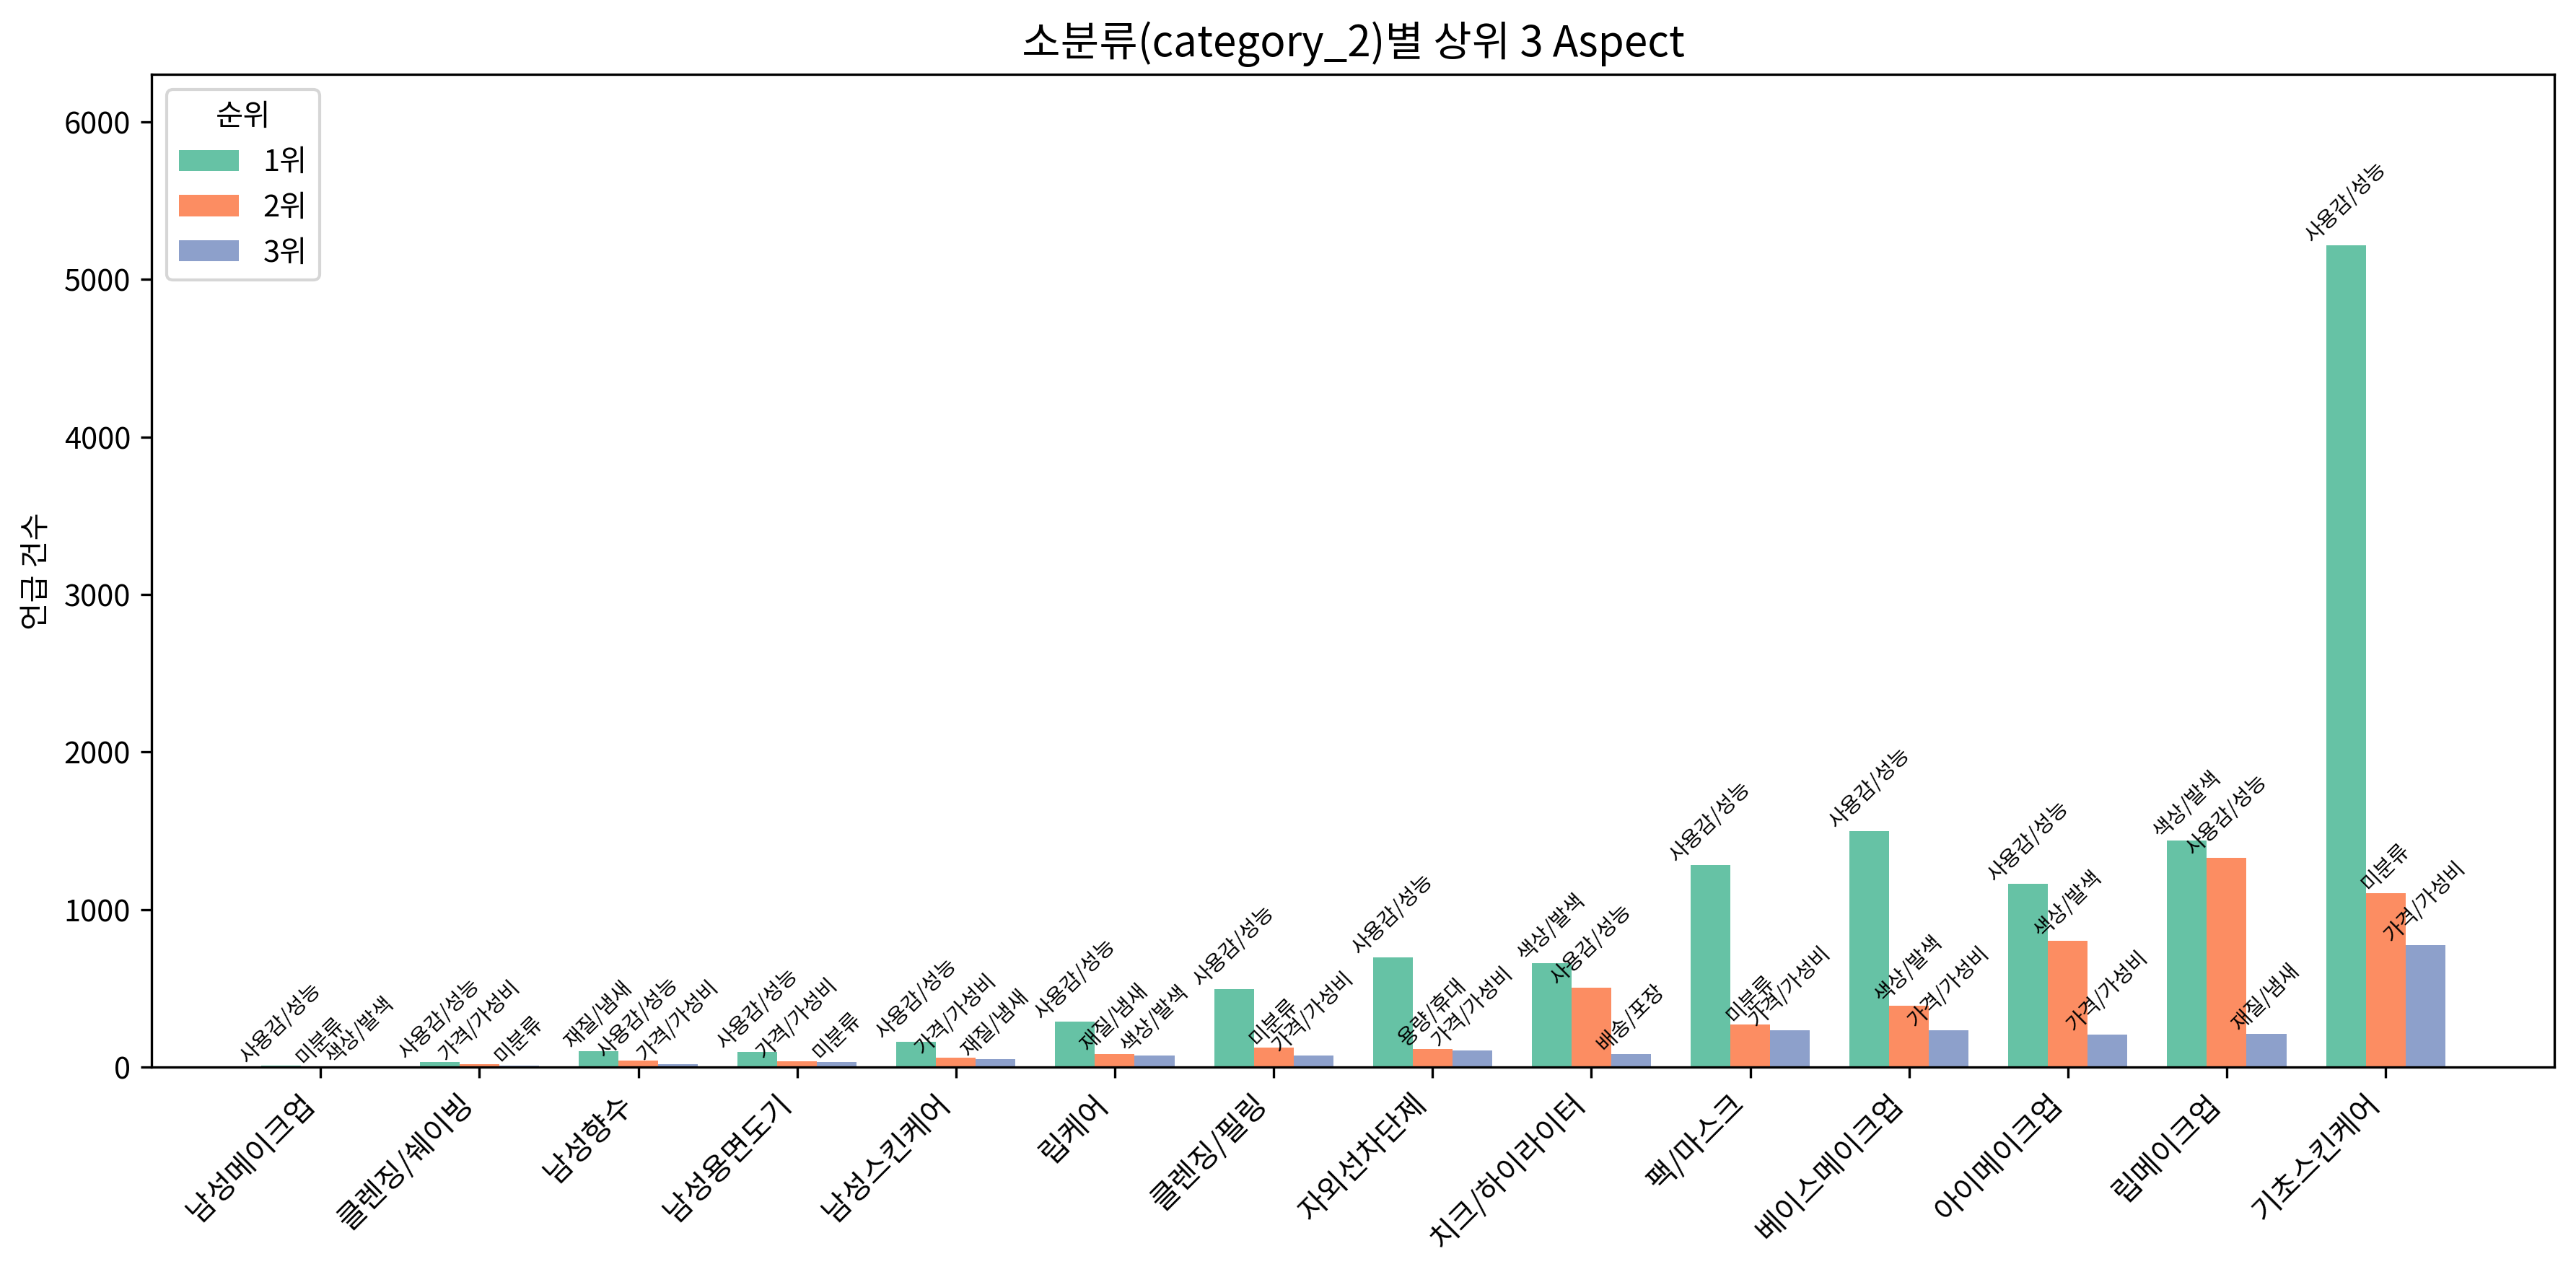

In [71]:
# 소분류별 상위 3 Aspect 그룹
fig, ax = plt.subplots(figsize=(12, 6))
cat2_order = cat2_top.groupby('category_2')['count'].sum().sort_values(ascending=True).index
cat2_top_sorted = cat2_top.set_index('category_2').loc[cat2_order].reset_index()
x_labels = cat2_top_sorted['category_2'].unique()
x_pos = np.arange(len(x_labels))
width = 0.25
for i, rank in enumerate([1, 2, 3]):
    subset = cat2_top_sorted[cat2_top_sorted['rank'] == rank]
    subset = subset.set_index('category_2').reindex(x_labels).reset_index()
    vals = subset['count'].fillna(0).values
    labels = subset['aspect'].values
    bars = ax.bar(x_pos + (i - 1) * width, vals, width, label=f'{rank}위')
    for j, (v, l) in enumerate(zip(vals, labels)):
        if v > 0 and pd.notna(l):
            ax.text(x_pos[j] + (i - 1) * width, v + 20, str(l)[:6], ha='center', fontsize=7, rotation=45)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel('언급 건수')
ax.set_title('소분류(category_2)별 상위 3 Aspect', fontsize=14)
ax.legend(title='순위')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()

## 6. 재구매 vs 비재구매 분석

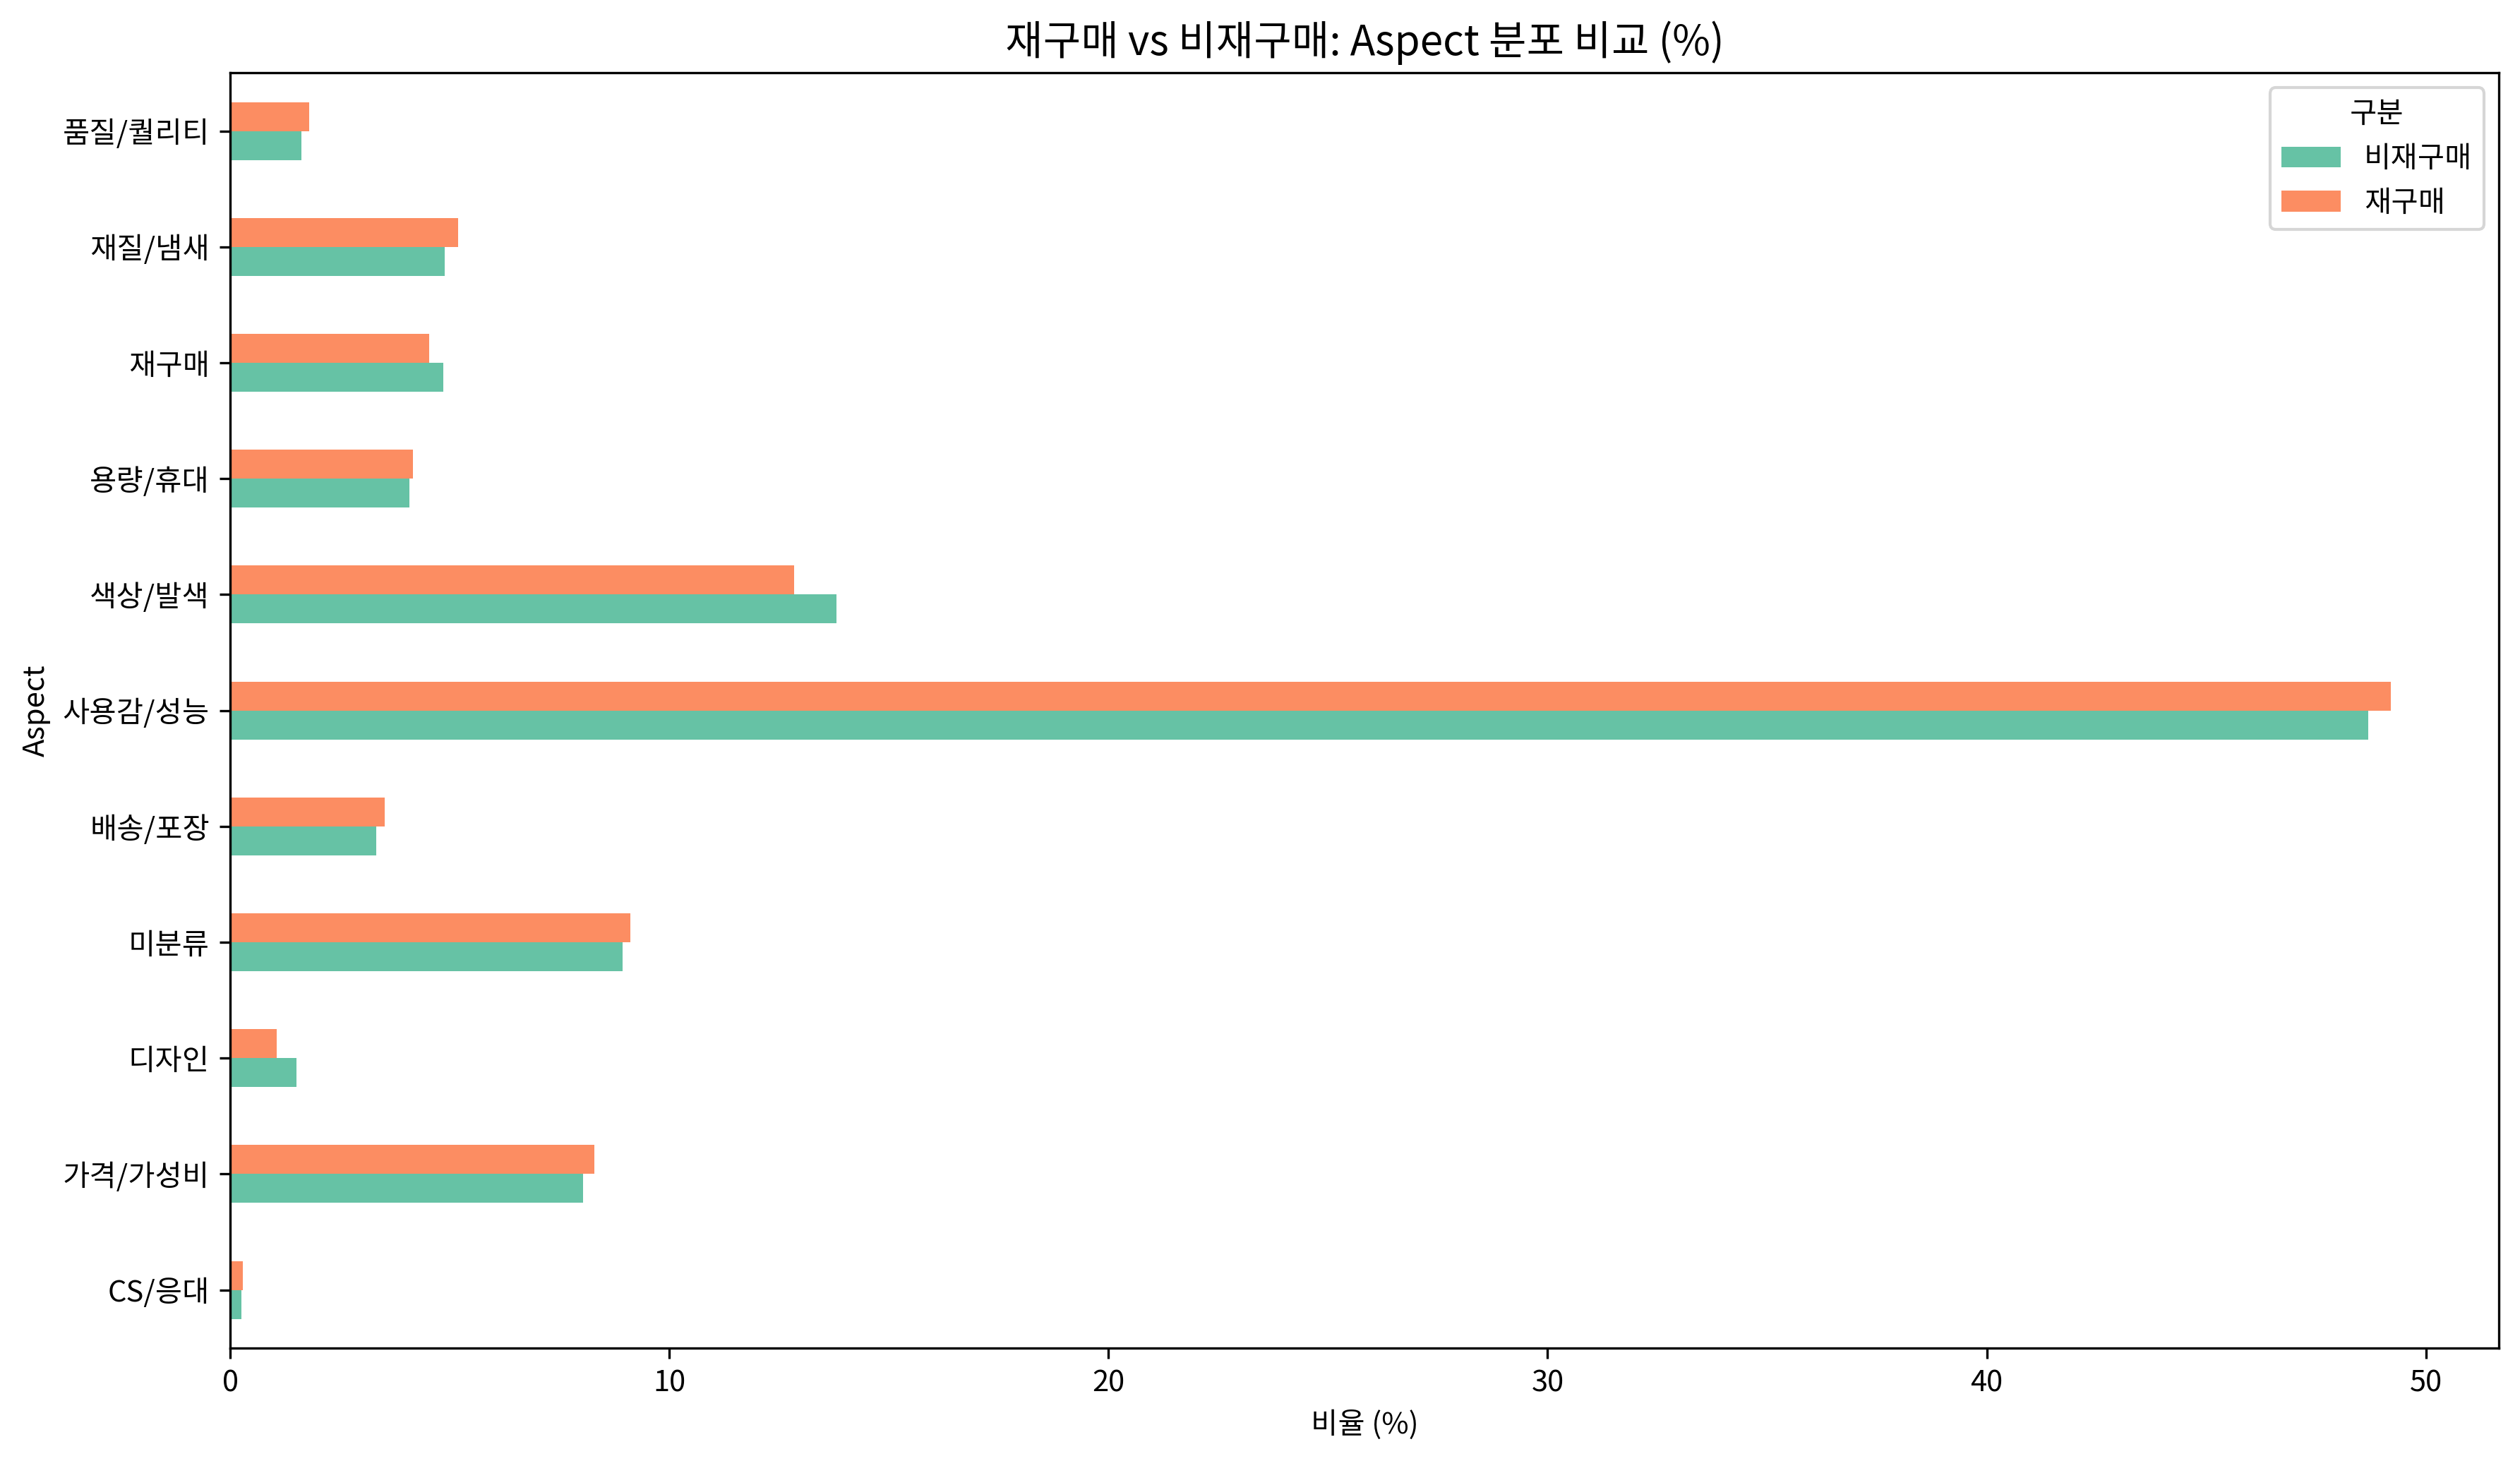

In [72]:
# is_reorder를 bool로 변환
df_reorder = df.dropna(subset=['is_reorder']).copy()
df_reorder['is_reorder'] = df_reorder['is_reorder'].astype(str).map({'True': True, 'False': False})
df_reorder = df_reorder.dropna(subset=['is_reorder'])

# 재구매/비재구매 그룹별 Aspect 분포
reorder_aspect = pd.crosstab(df_reorder['aspect'],
                              df_reorder['is_reorder'].map({True: '재구매', False: '비재구매'}),
                              normalize='columns') * 100

fig, ax = plt.subplots(figsize=(12, 7))
reorder_aspect.plot(kind='barh', ax=ax)
ax.set_title('재구매 vs 비재구매: Aspect 분포 비교 (%)', fontsize=14)
ax.set_xlabel('비율 (%)')
ax.set_ylabel('Aspect')
ax.legend(title='구분')
plt.tight_layout()
plt.show()

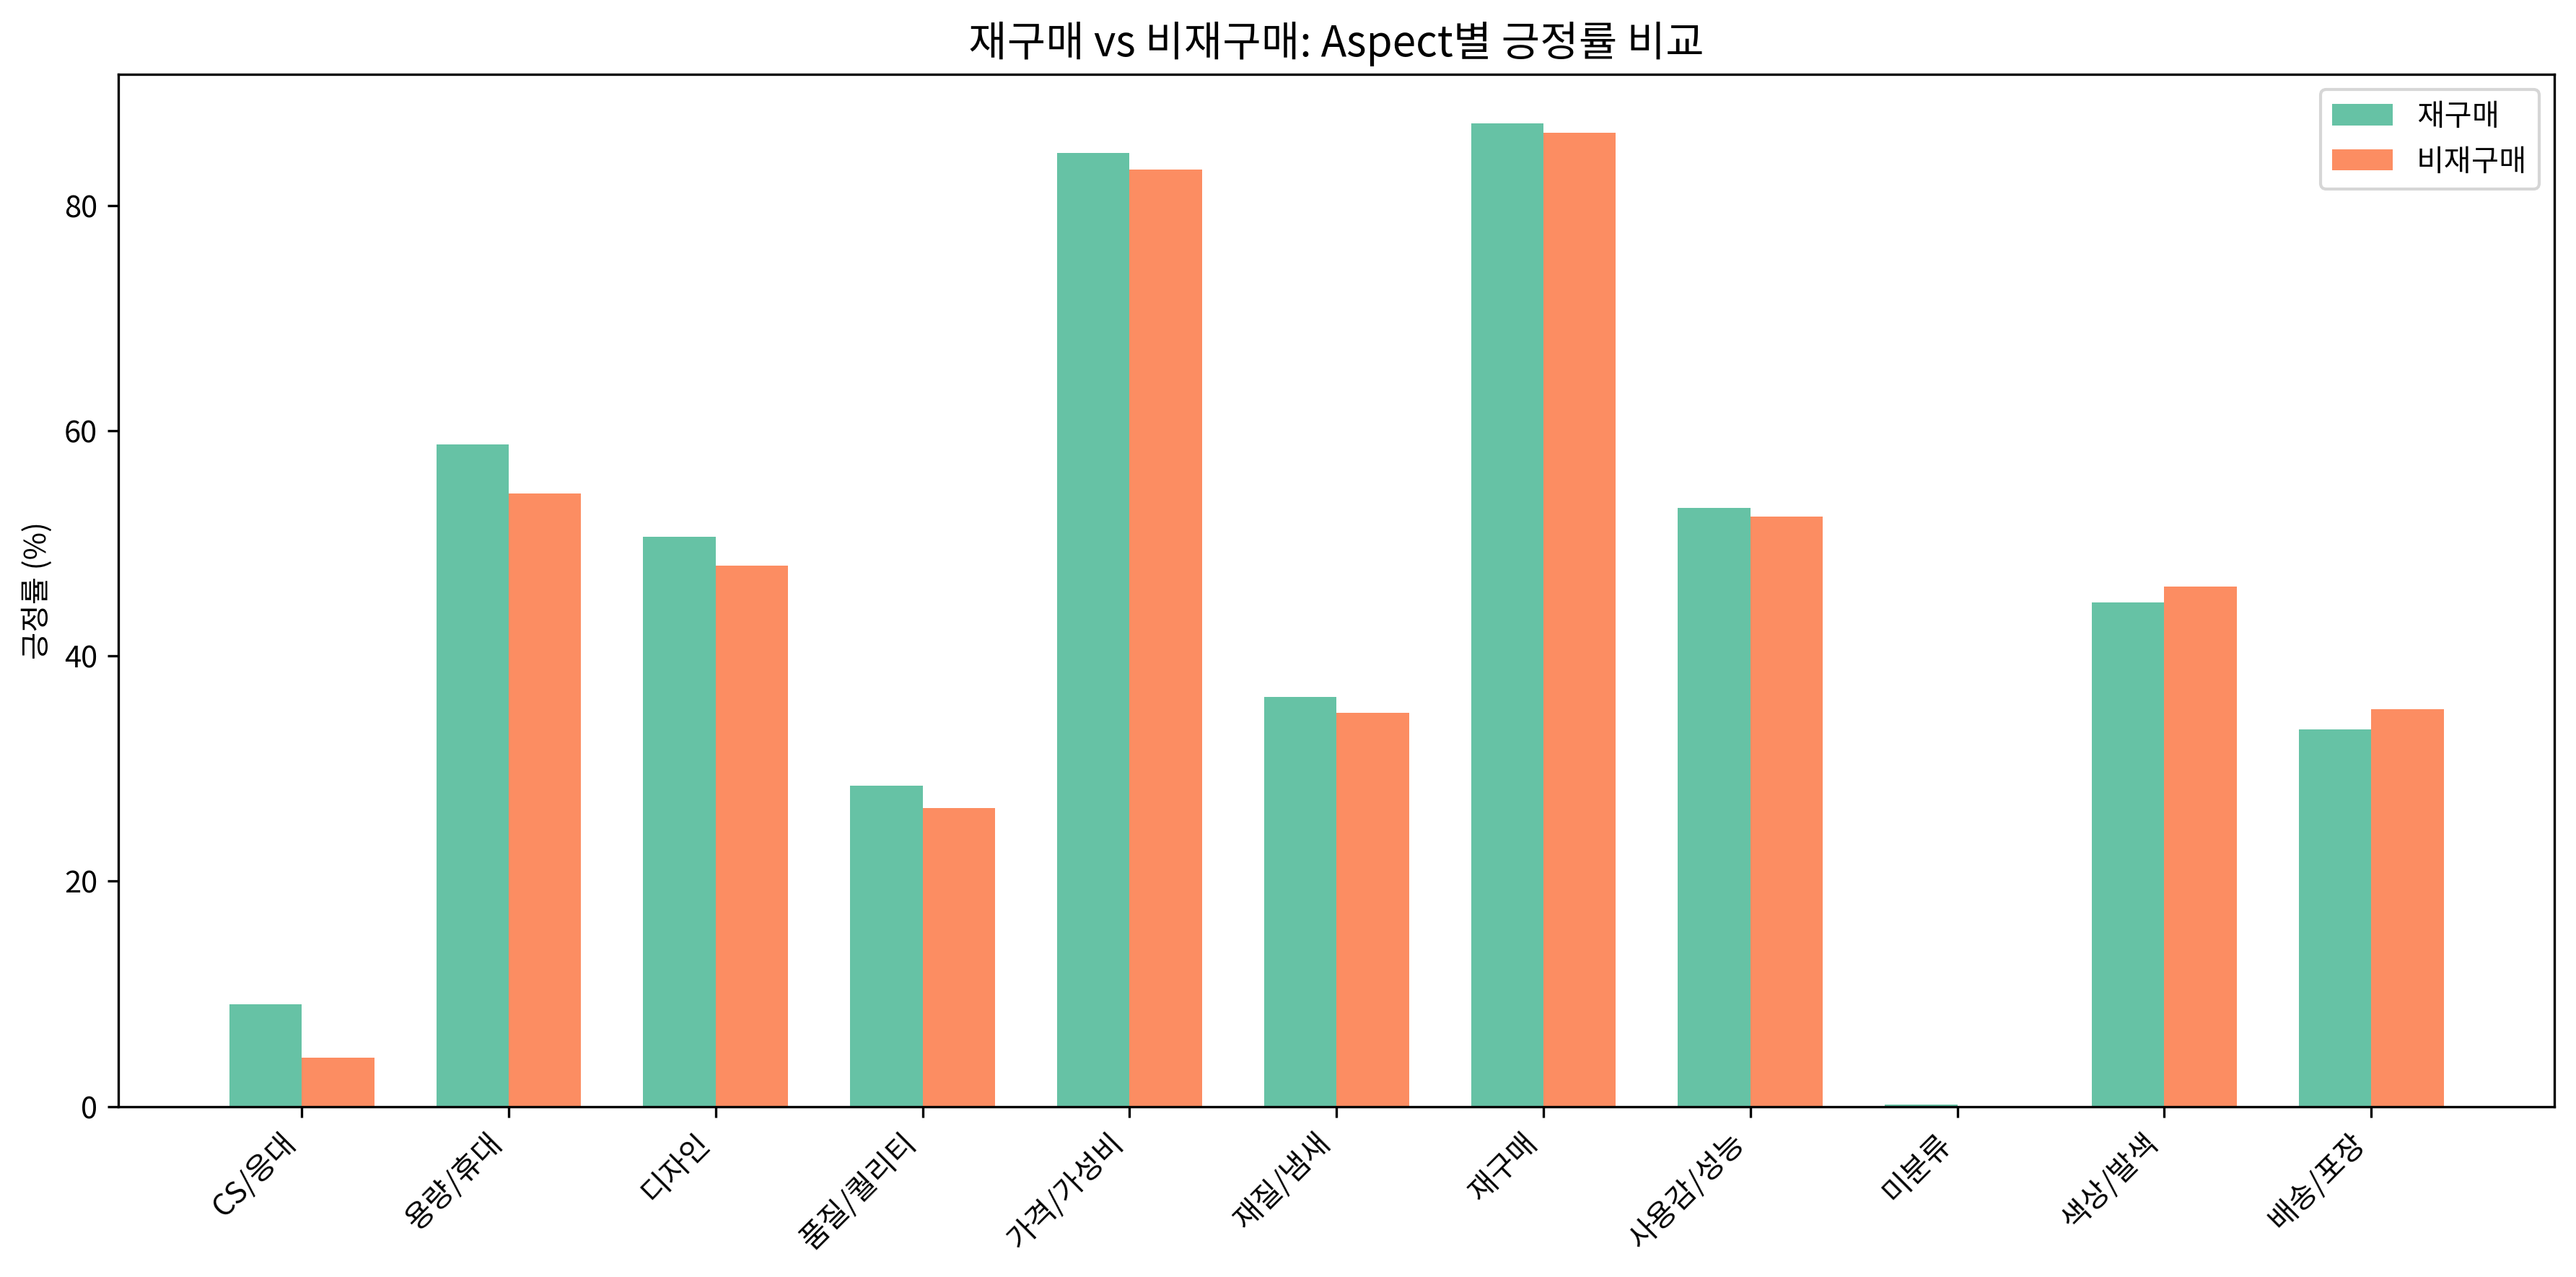

In [73]:
# 재구매 그룹의 긍정률 vs 비재구매 그룹
reorder_sent = df_reorder.groupby(['is_reorder', 'aspect', 'aspect_sentiment']).size().reset_index(name='count')
reorder_total = df_reorder.groupby(['is_reorder', 'aspect']).size().reset_index(name='total')
reorder_merged = reorder_sent.merge(reorder_total, on=['is_reorder', 'aspect'])
reorder_merged['rate'] = reorder_merged['count'] / reorder_merged['total'] * 100

# 긍정률 비교
pos_rate = reorder_merged[reorder_merged['aspect_sentiment'] == 'positive'].copy()
pos_pivot = pos_rate.pivot_table(index='aspect', columns='is_reorder', values='rate', fill_value=0)
pos_pivot.columns = ['비재구매 긍정률', '재구매 긍정률']
pos_pivot['차이'] = pos_pivot['재구매 긍정률'] - pos_pivot['비재구매 긍정률']
pos_pivot = pos_pivot.sort_values('차이', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pos_pivot))
width = 0.35
ax.bar(x - width/2, pos_pivot['재구매 긍정률'], width, label='재구매', color='#66c2a5')
ax.bar(x + width/2, pos_pivot['비재구매 긍정률'], width, label='비재구매', color='#fc8d62')
ax.set_xticks(x)
ax.set_xticklabels(pos_pivot.index, rotation=45, ha='right')
ax.set_title('재구매 vs 비재구매: Aspect별 긍정률 비교', fontsize=14)
ax.set_ylabel('긍정률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

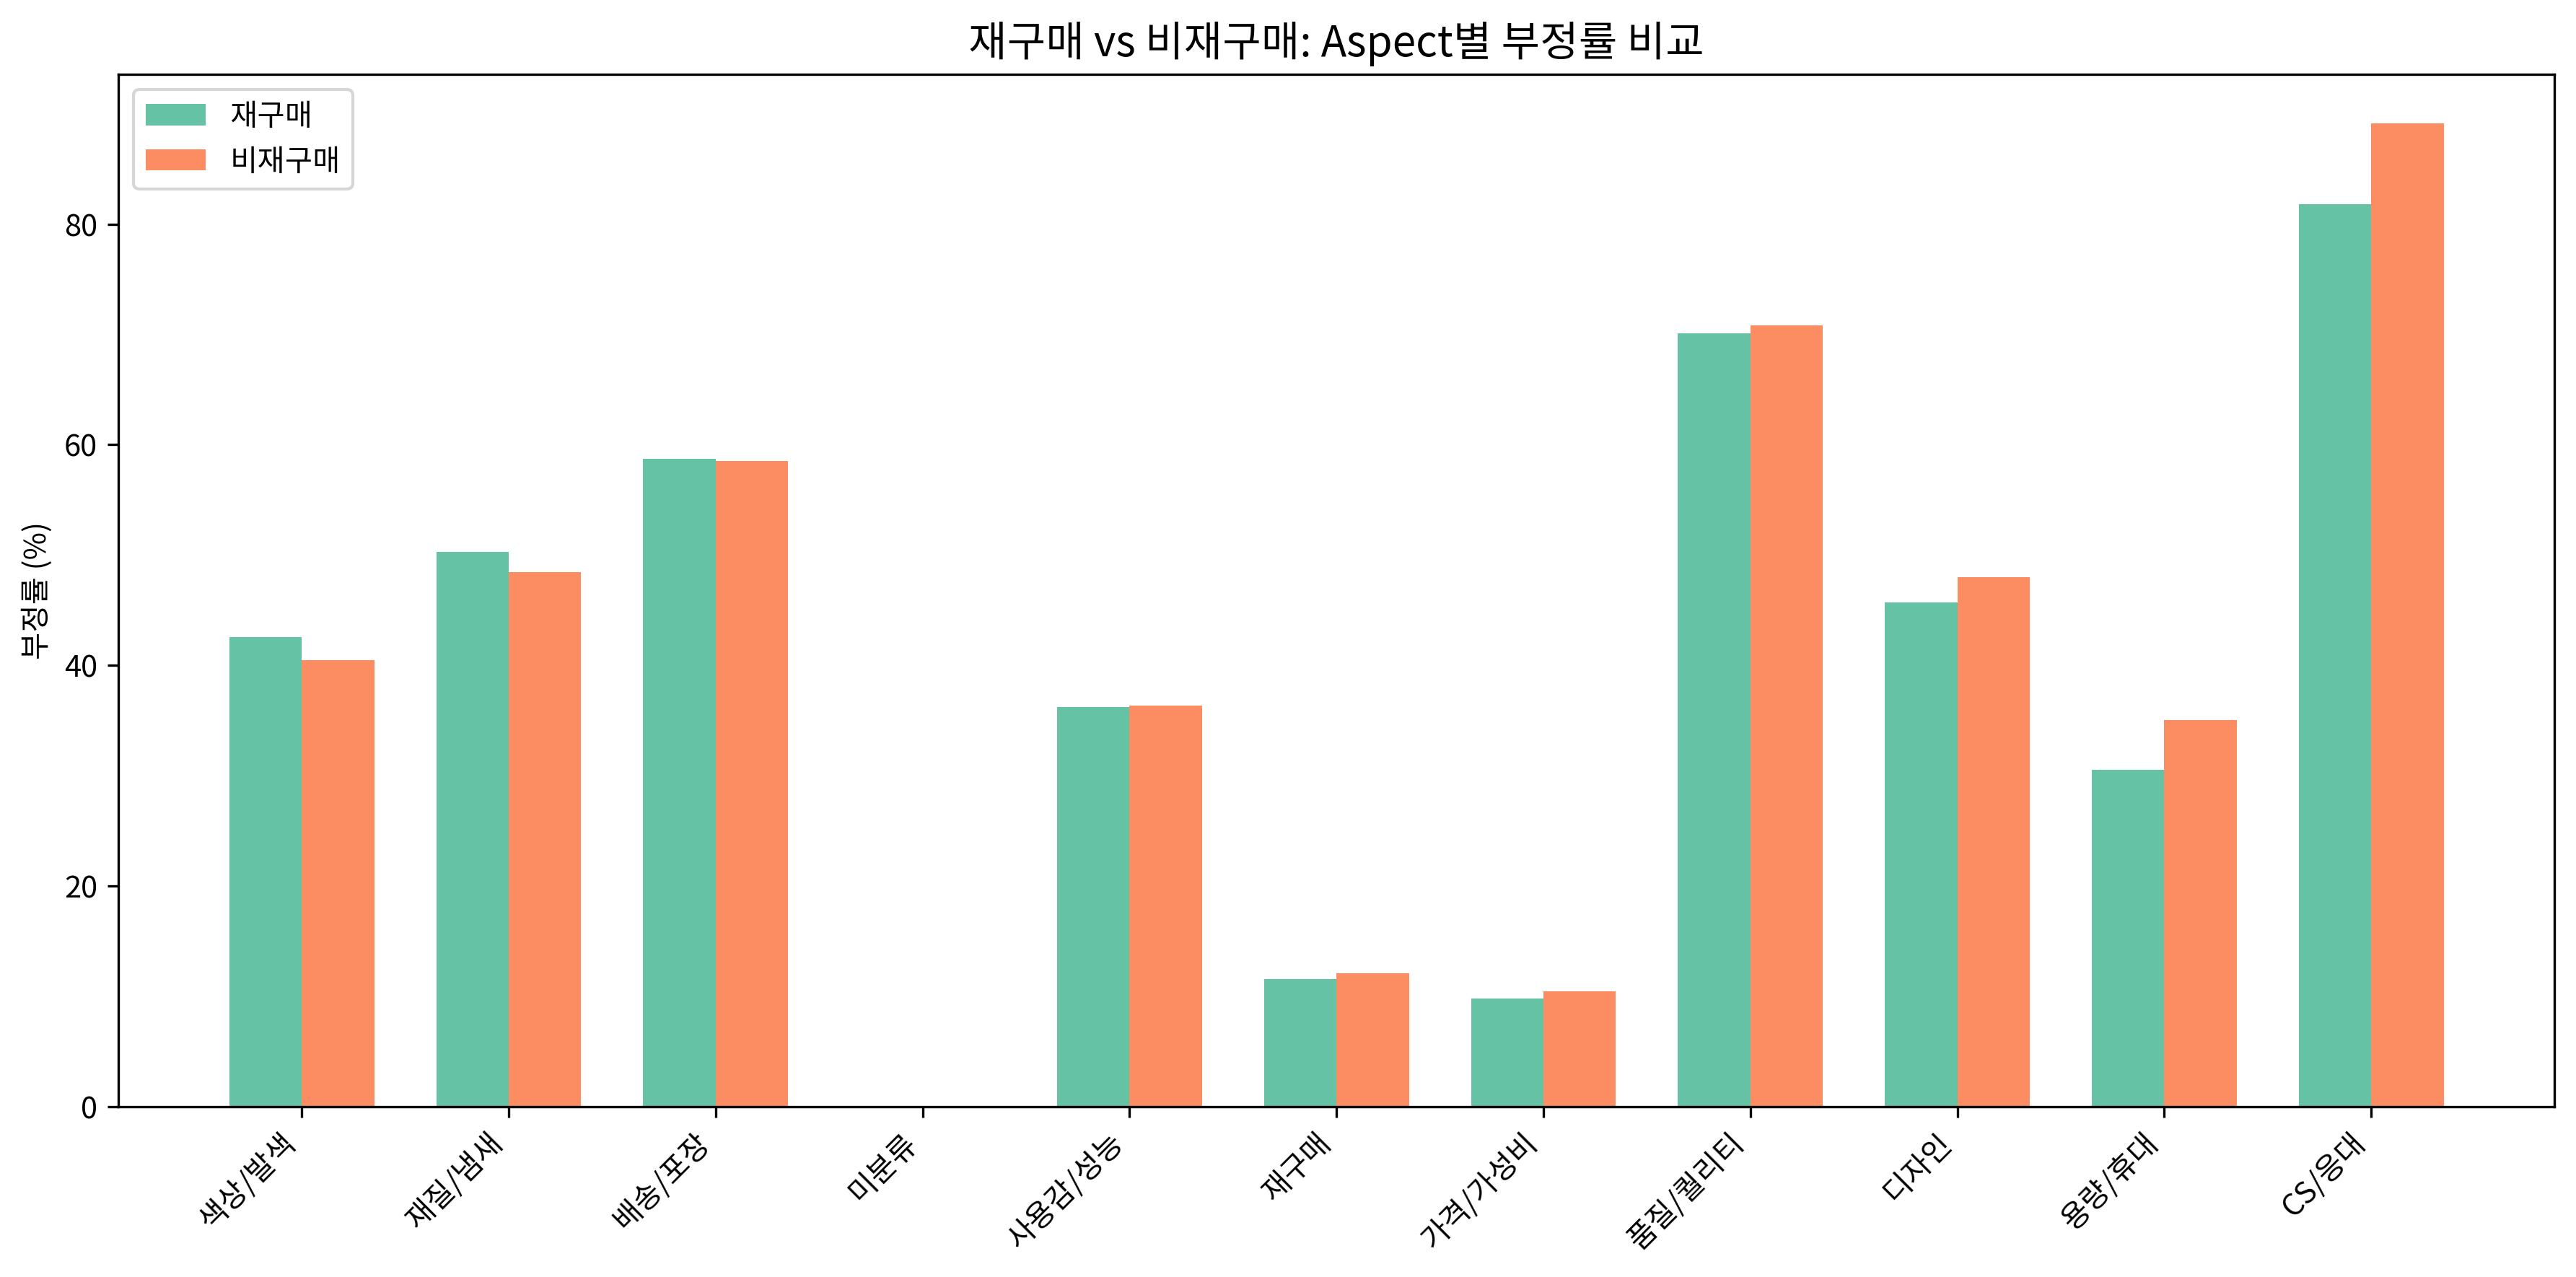

In [74]:
# 부정률 비교
neg_rate = reorder_merged[reorder_merged['aspect_sentiment'] == 'negative'].copy()
neg_pivot = neg_rate.pivot_table(index='aspect', columns='is_reorder', values='rate', fill_value=0)
neg_pivot.columns = ['비재구매 부정률', '재구매 부정률']
neg_pivot['차이'] = neg_pivot['재구매 부정률'] - neg_pivot['비재구매 부정률']
neg_pivot = neg_pivot.sort_values('차이', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(neg_pivot))
width = 0.35
ax.bar(x - width/2, neg_pivot['재구매 부정률'], width, label='재구매', color='#66c2a5')
ax.bar(x + width/2, neg_pivot['비재구매 부정률'], width, label='비재구매', color='#fc8d62')
ax.set_xticks(x)
ax.set_xticklabels(neg_pivot.index, rotation=45, ha='right')
ax.set_title('재구매 vs 비재구매: Aspect별 부정률 비교', fontsize=14)
ax.set_ylabel('부정률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. 가격대별 분석

In [75]:
# 가격대 구분
bins = [0, 1000, 2000, 3000, 5000]
labels = ['~1,000원', '~2,000원', '~3,000원', '~5,000원']
df_price = df.dropna(subset=['price']).copy()
df_price['price_range'] = pd.cut(df_price['price'], bins=bins, labels=labels, include_lowest=True)

print("가격대별 분포:")
print(df_price['price_range'].value_counts().sort_index())

가격대별 분포:
price_range
~1,000원     1615
~2,000원     1320
~3,000원    11699
~5,000원    11588
Name: count, dtype: int64


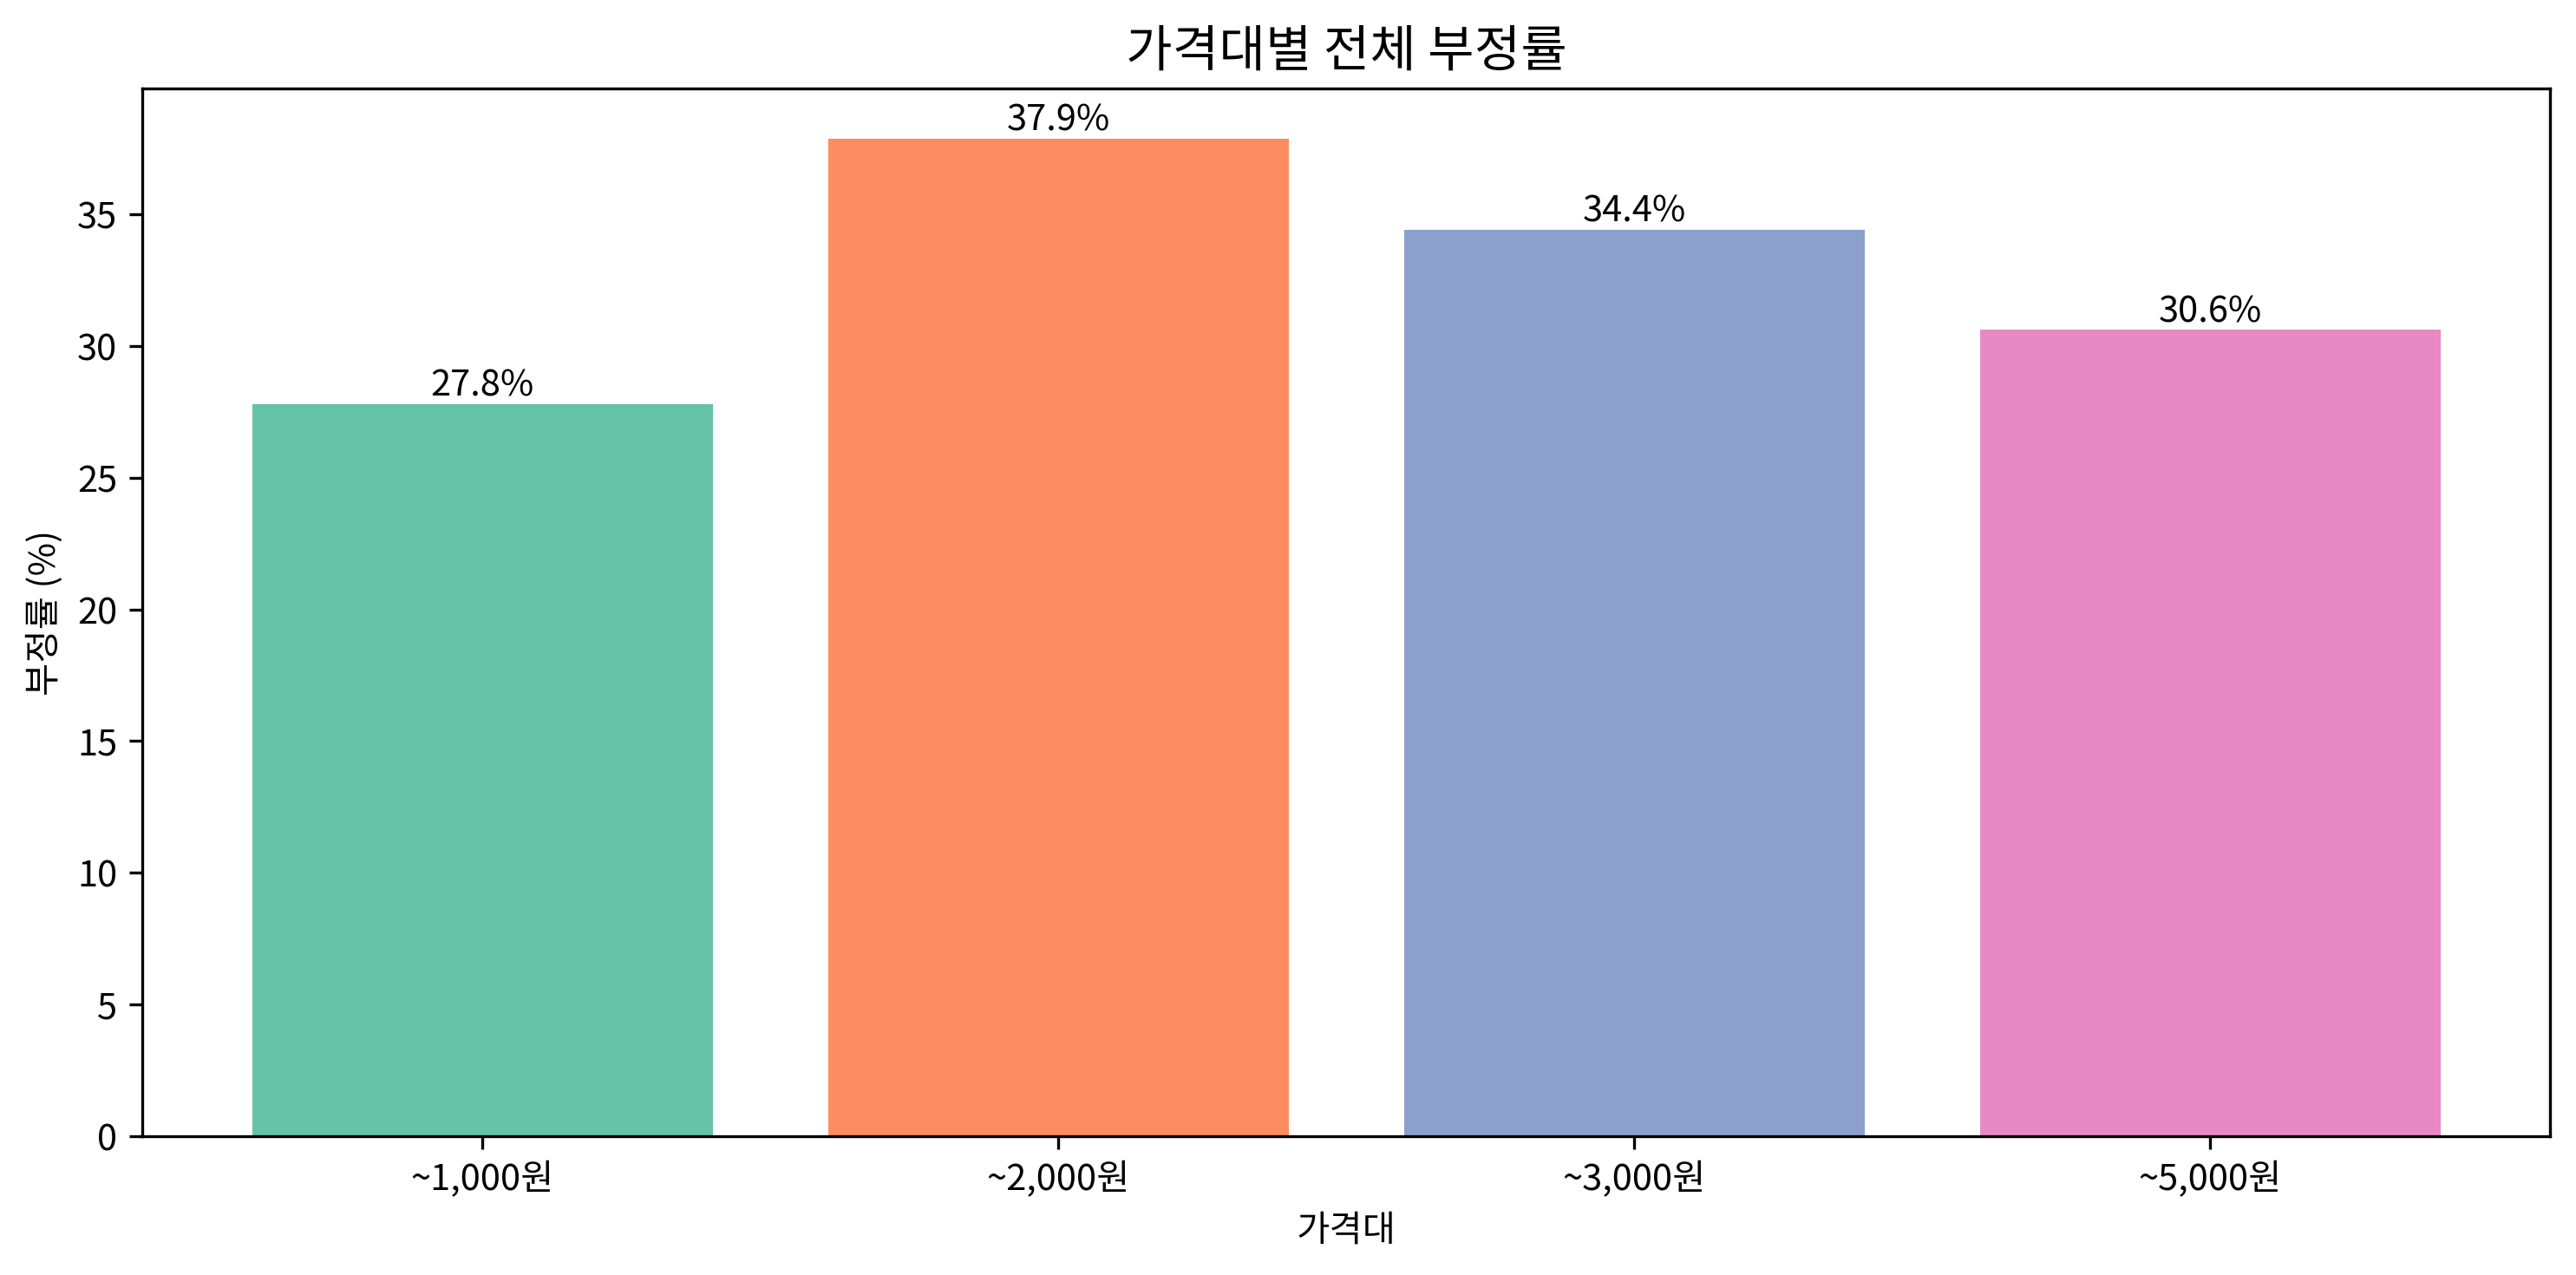

In [76]:
# 가격대별 Aspect sentiment 비율
price_sent = pd.crosstab([df_price['price_range'], df_price['aspect']],
                          df_price['aspect_sentiment'], normalize='index') * 100
price_sent = price_sent.reset_index()

# 가격대별 부정률
price_neg = df_price.groupby('price_range').apply(
    lambda x: (x['aspect_sentiment'] == 'negative').mean() * 100
).reset_index(name='부정률')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(price_neg['price_range'].astype(str), price_neg['부정률'], color=sns.color_palette('Set2'))
ax.set_title('가격대별 전체 부정률', fontsize=14)
ax.set_xlabel('가격대')
ax.set_ylabel('부정률 (%)')
for i, v in enumerate(price_neg['부정률']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

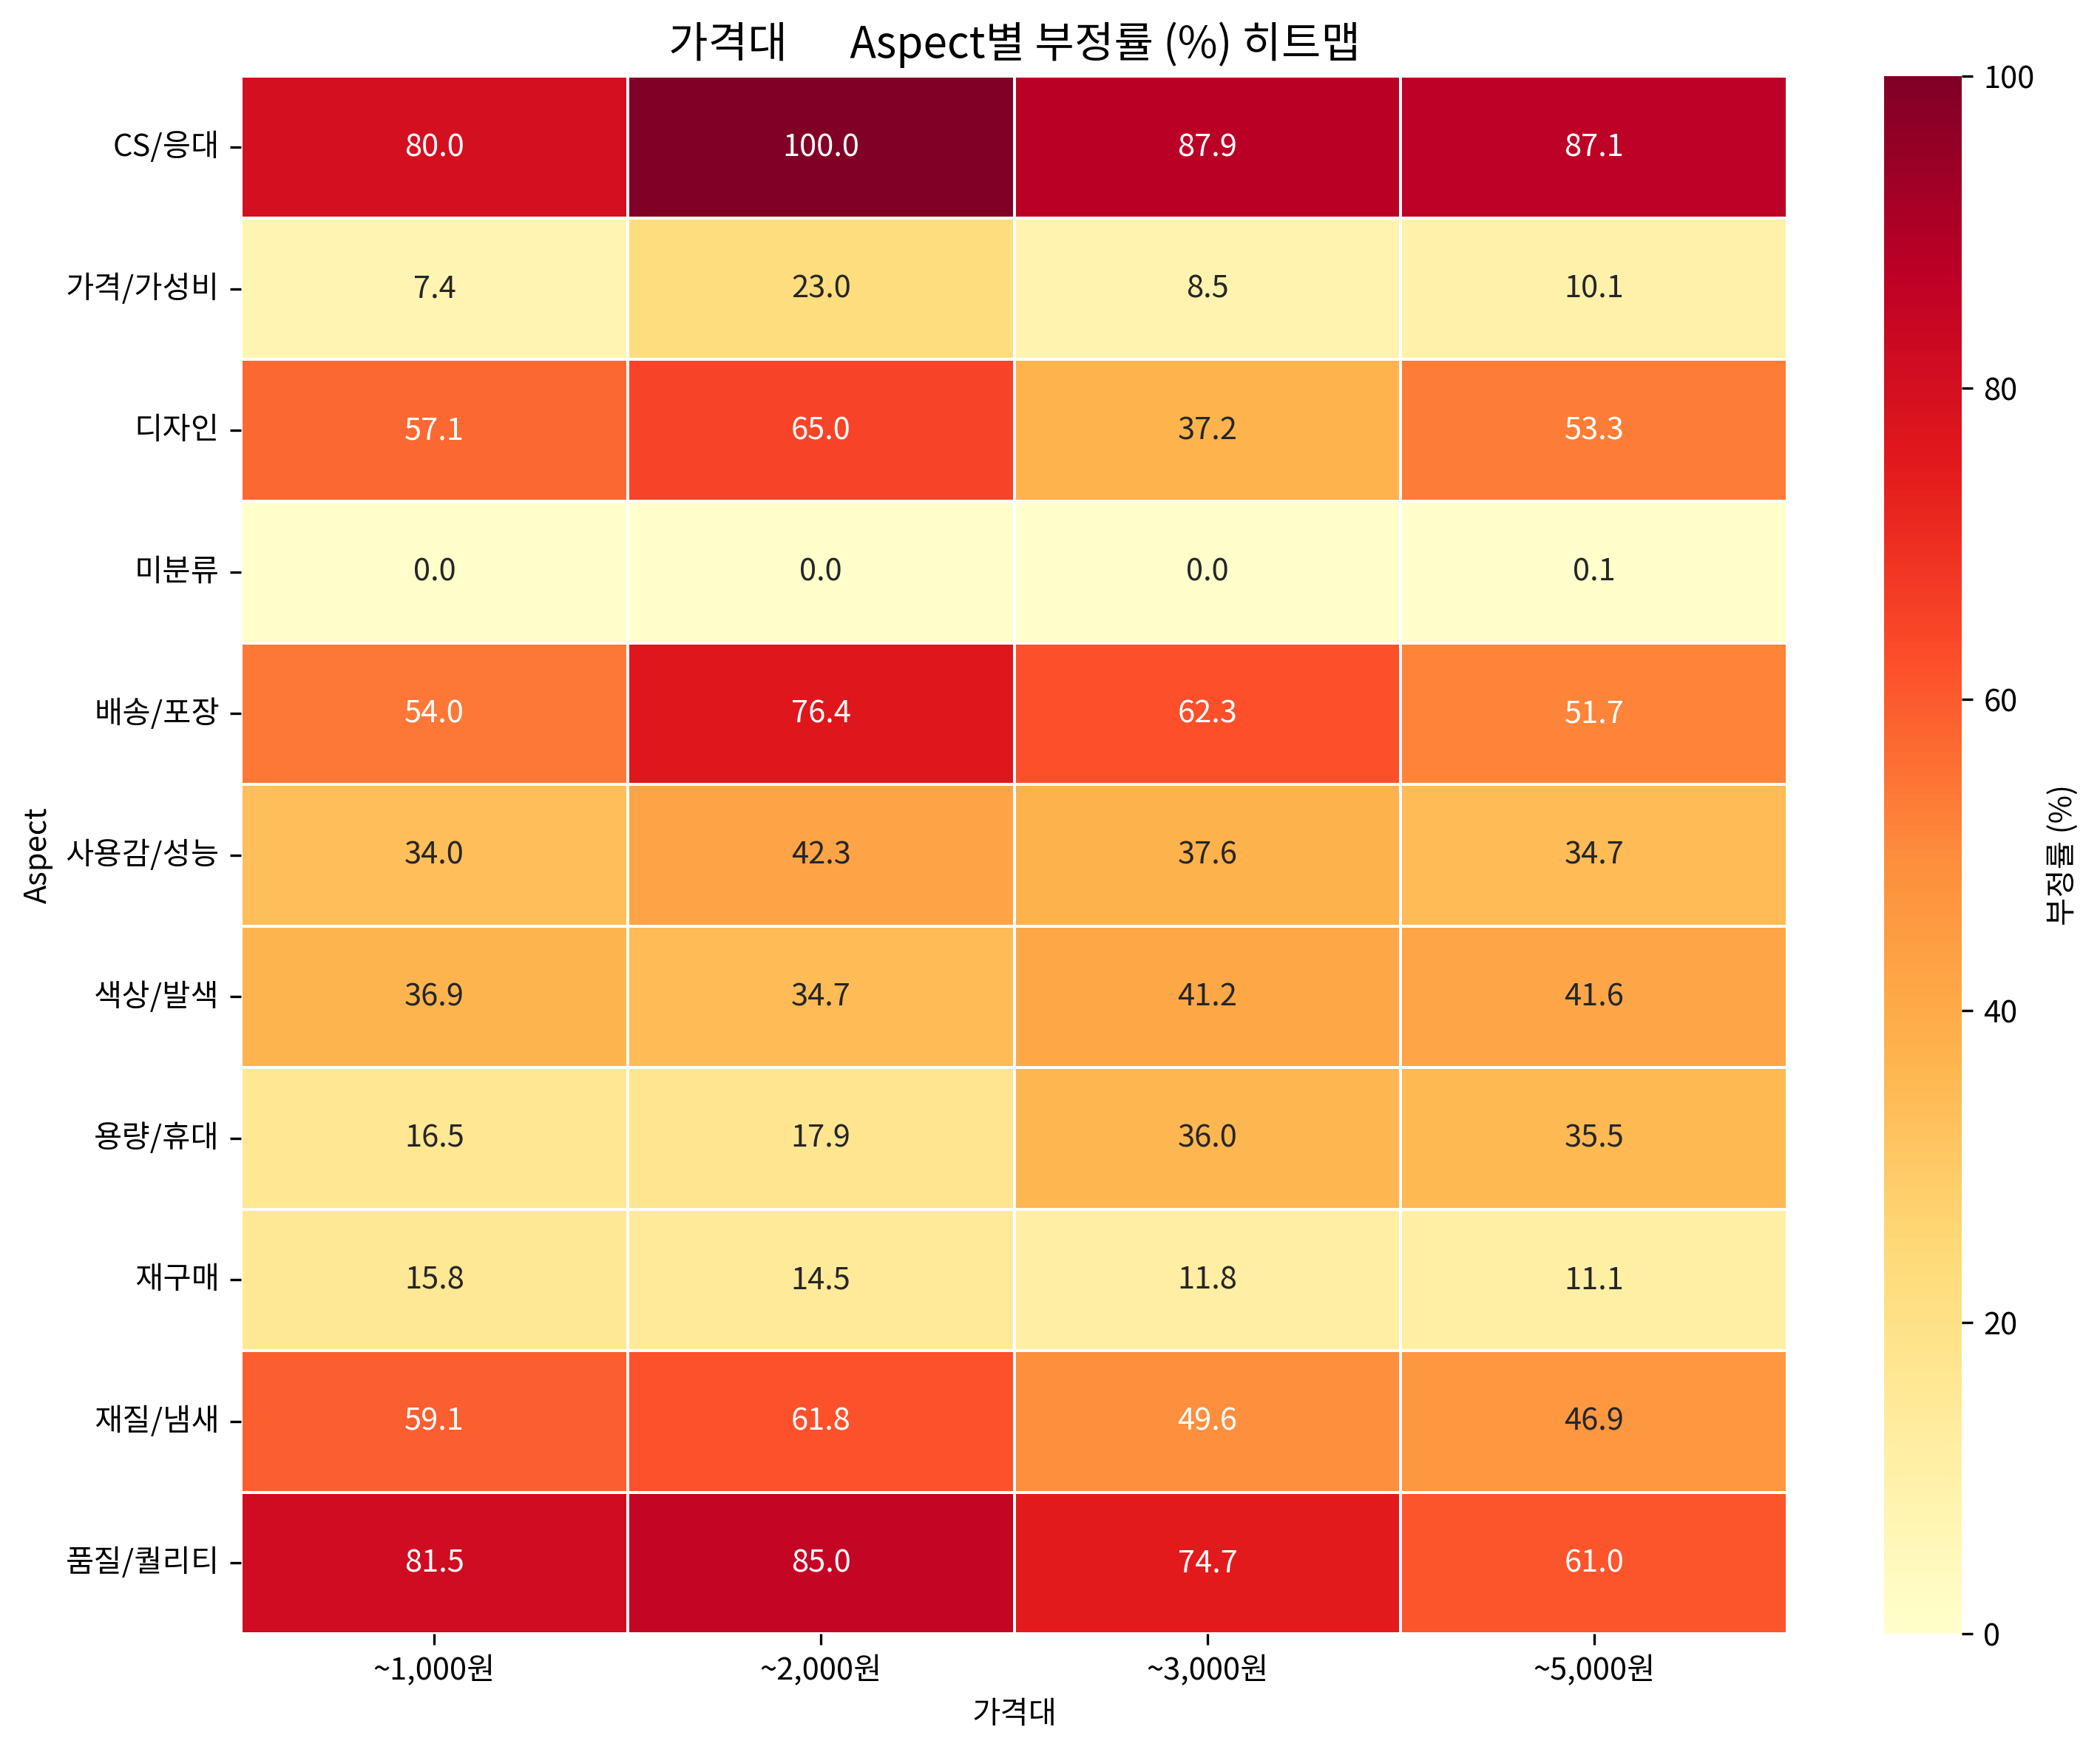

In [77]:
# 가격대별 × Aspect별 부정률 히트맵
price_aspect_neg = df_price.pivot_table(
    index='aspect',
    columns='price_range',
    values='aspect_sentiment',
    aggfunc=lambda x: (x == 'negative').mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(price_aspect_neg, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '부정률 (%)'})
ax.set_title('가격대 × Aspect별 부정률 (%) 히트맵', fontsize=14)
ax.set_ylabel('Aspect')
ax.set_xlabel('가격대')
plt.tight_layout()
plt.show()

## 8. 부정 리뷰 집중 분석 (리스크 진단)

In [78]:
df_negative = df[df['aspect_sentiment'] == 'negative'].copy()
print(f"전체 부정 건수: {len(df_negative):,} ({len(df_negative)/len(df)*100:.1f}%)")
print(f"부정 리뷰 관련 고유 상품 수: {df_negative['product_code'].nunique():,}")

전체 부정 건수: 8,544 (32.5%)
부정 리뷰 관련 고유 상품 수: 753


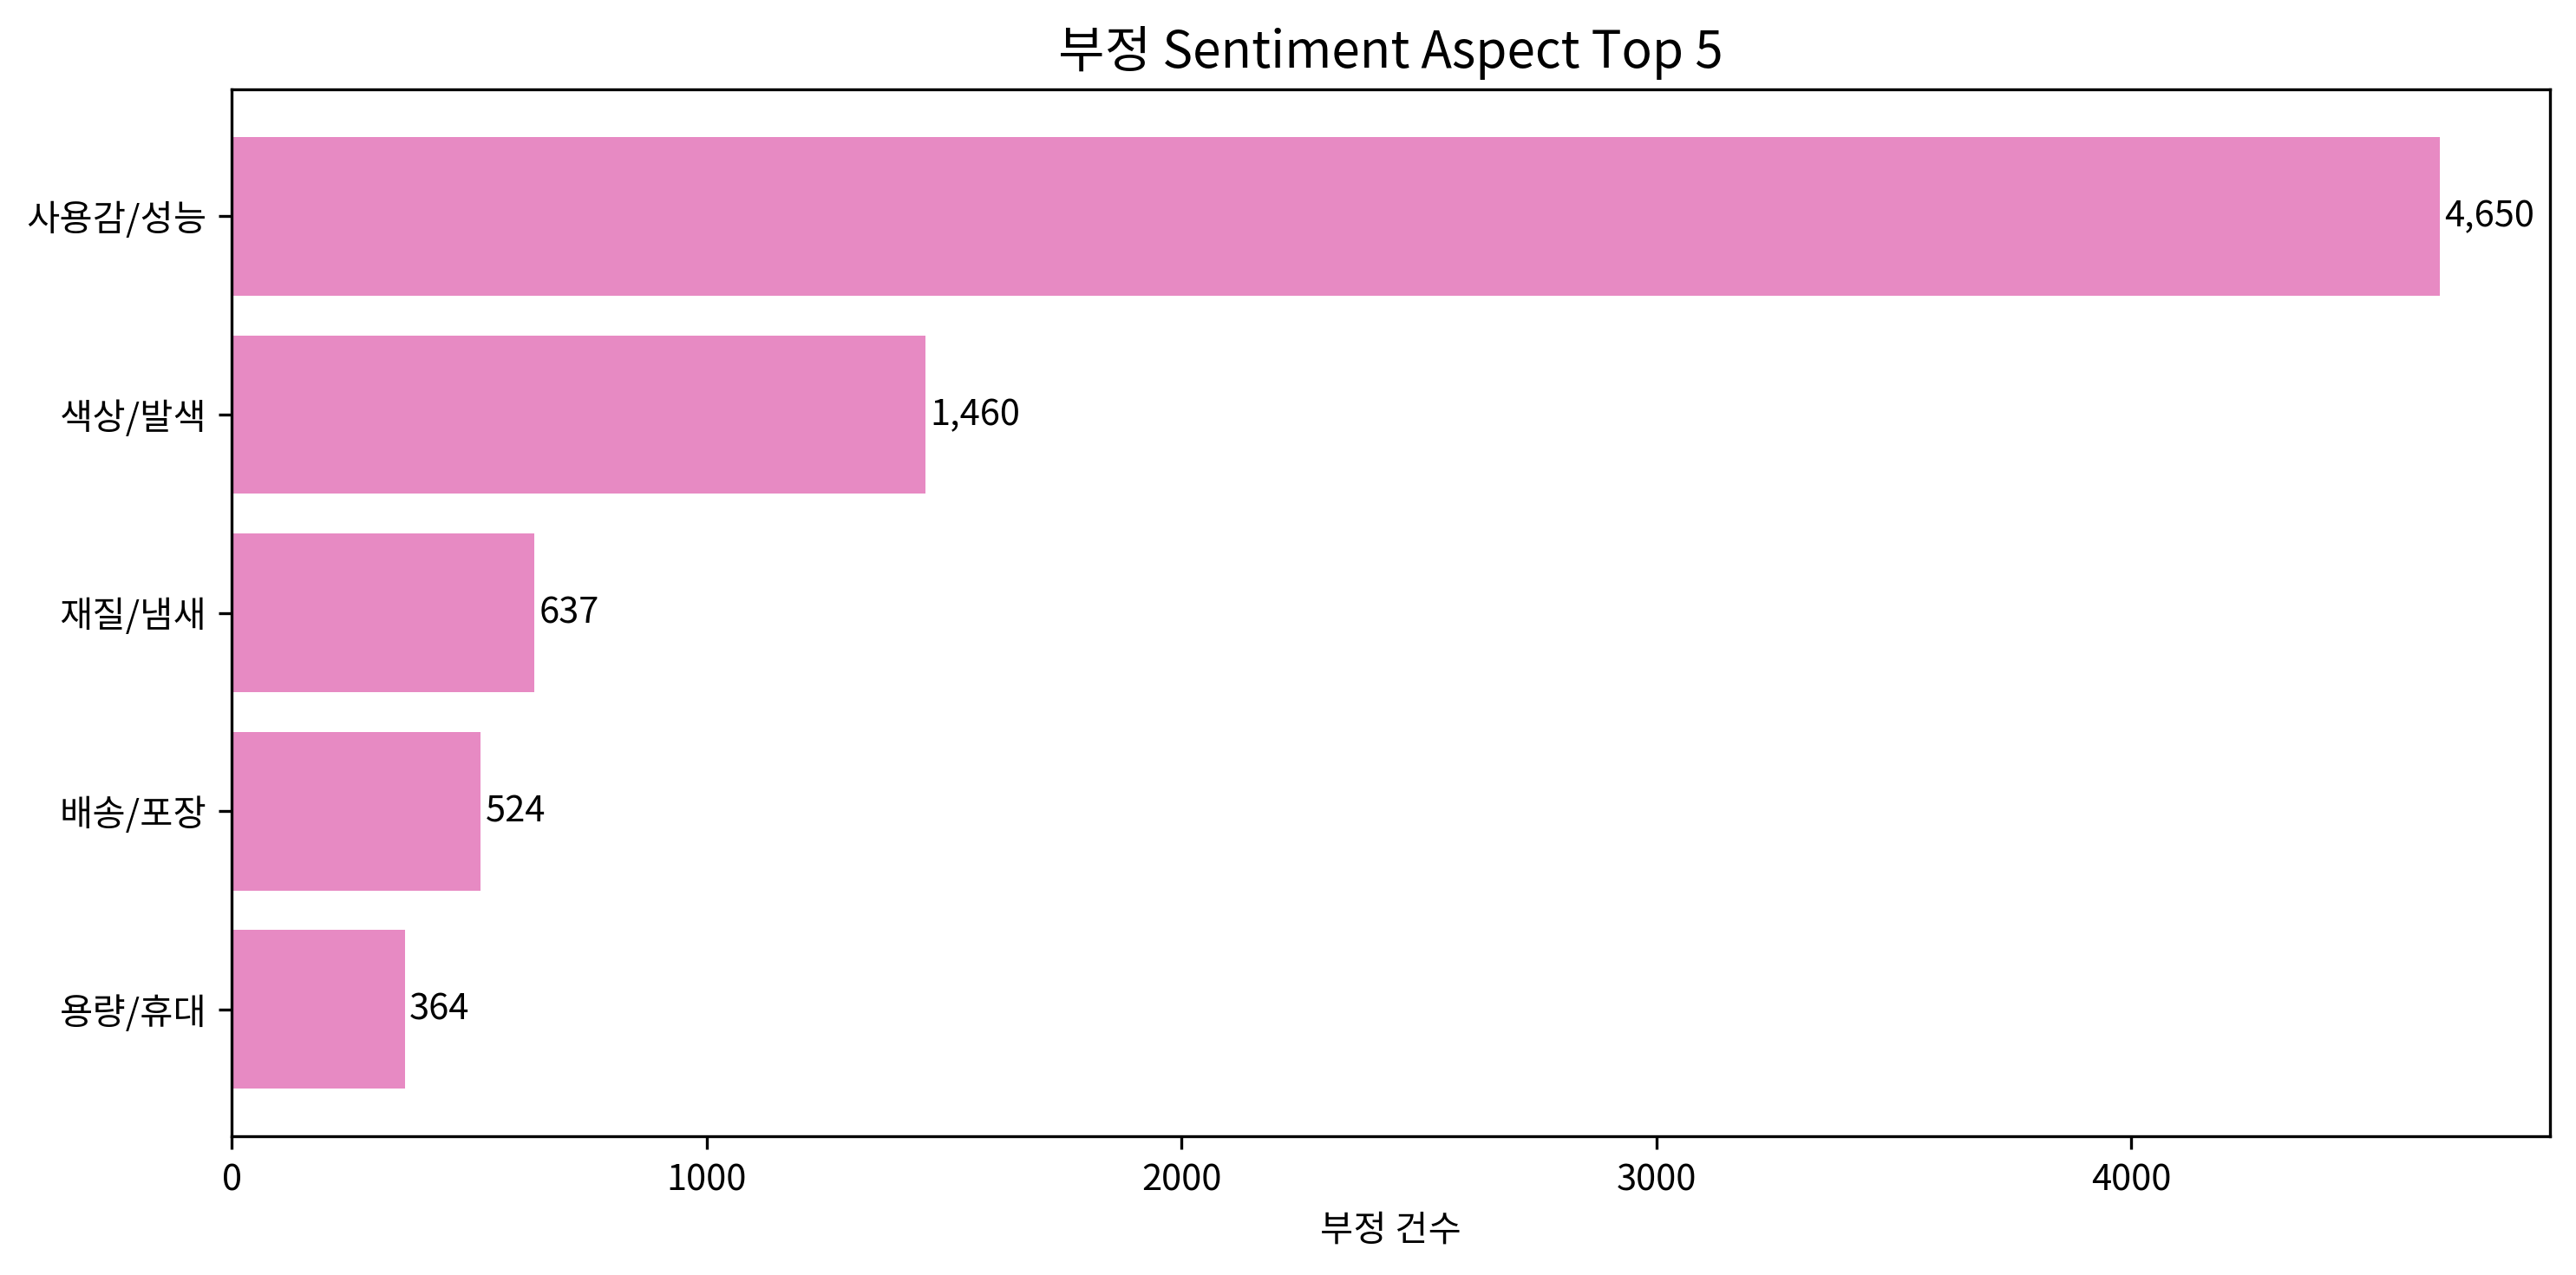

In [79]:
# Aspect별 부정 건수 Top 5
neg_aspect = df_negative['aspect'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
top5 = neg_aspect.head(5)
bars = ax.barh(top5.index[::-1], top5.values[::-1], color='#e78ac3')
ax.set_title('부정 Sentiment Aspect Top 5', fontsize=14)
ax.set_xlabel('부정 건수')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

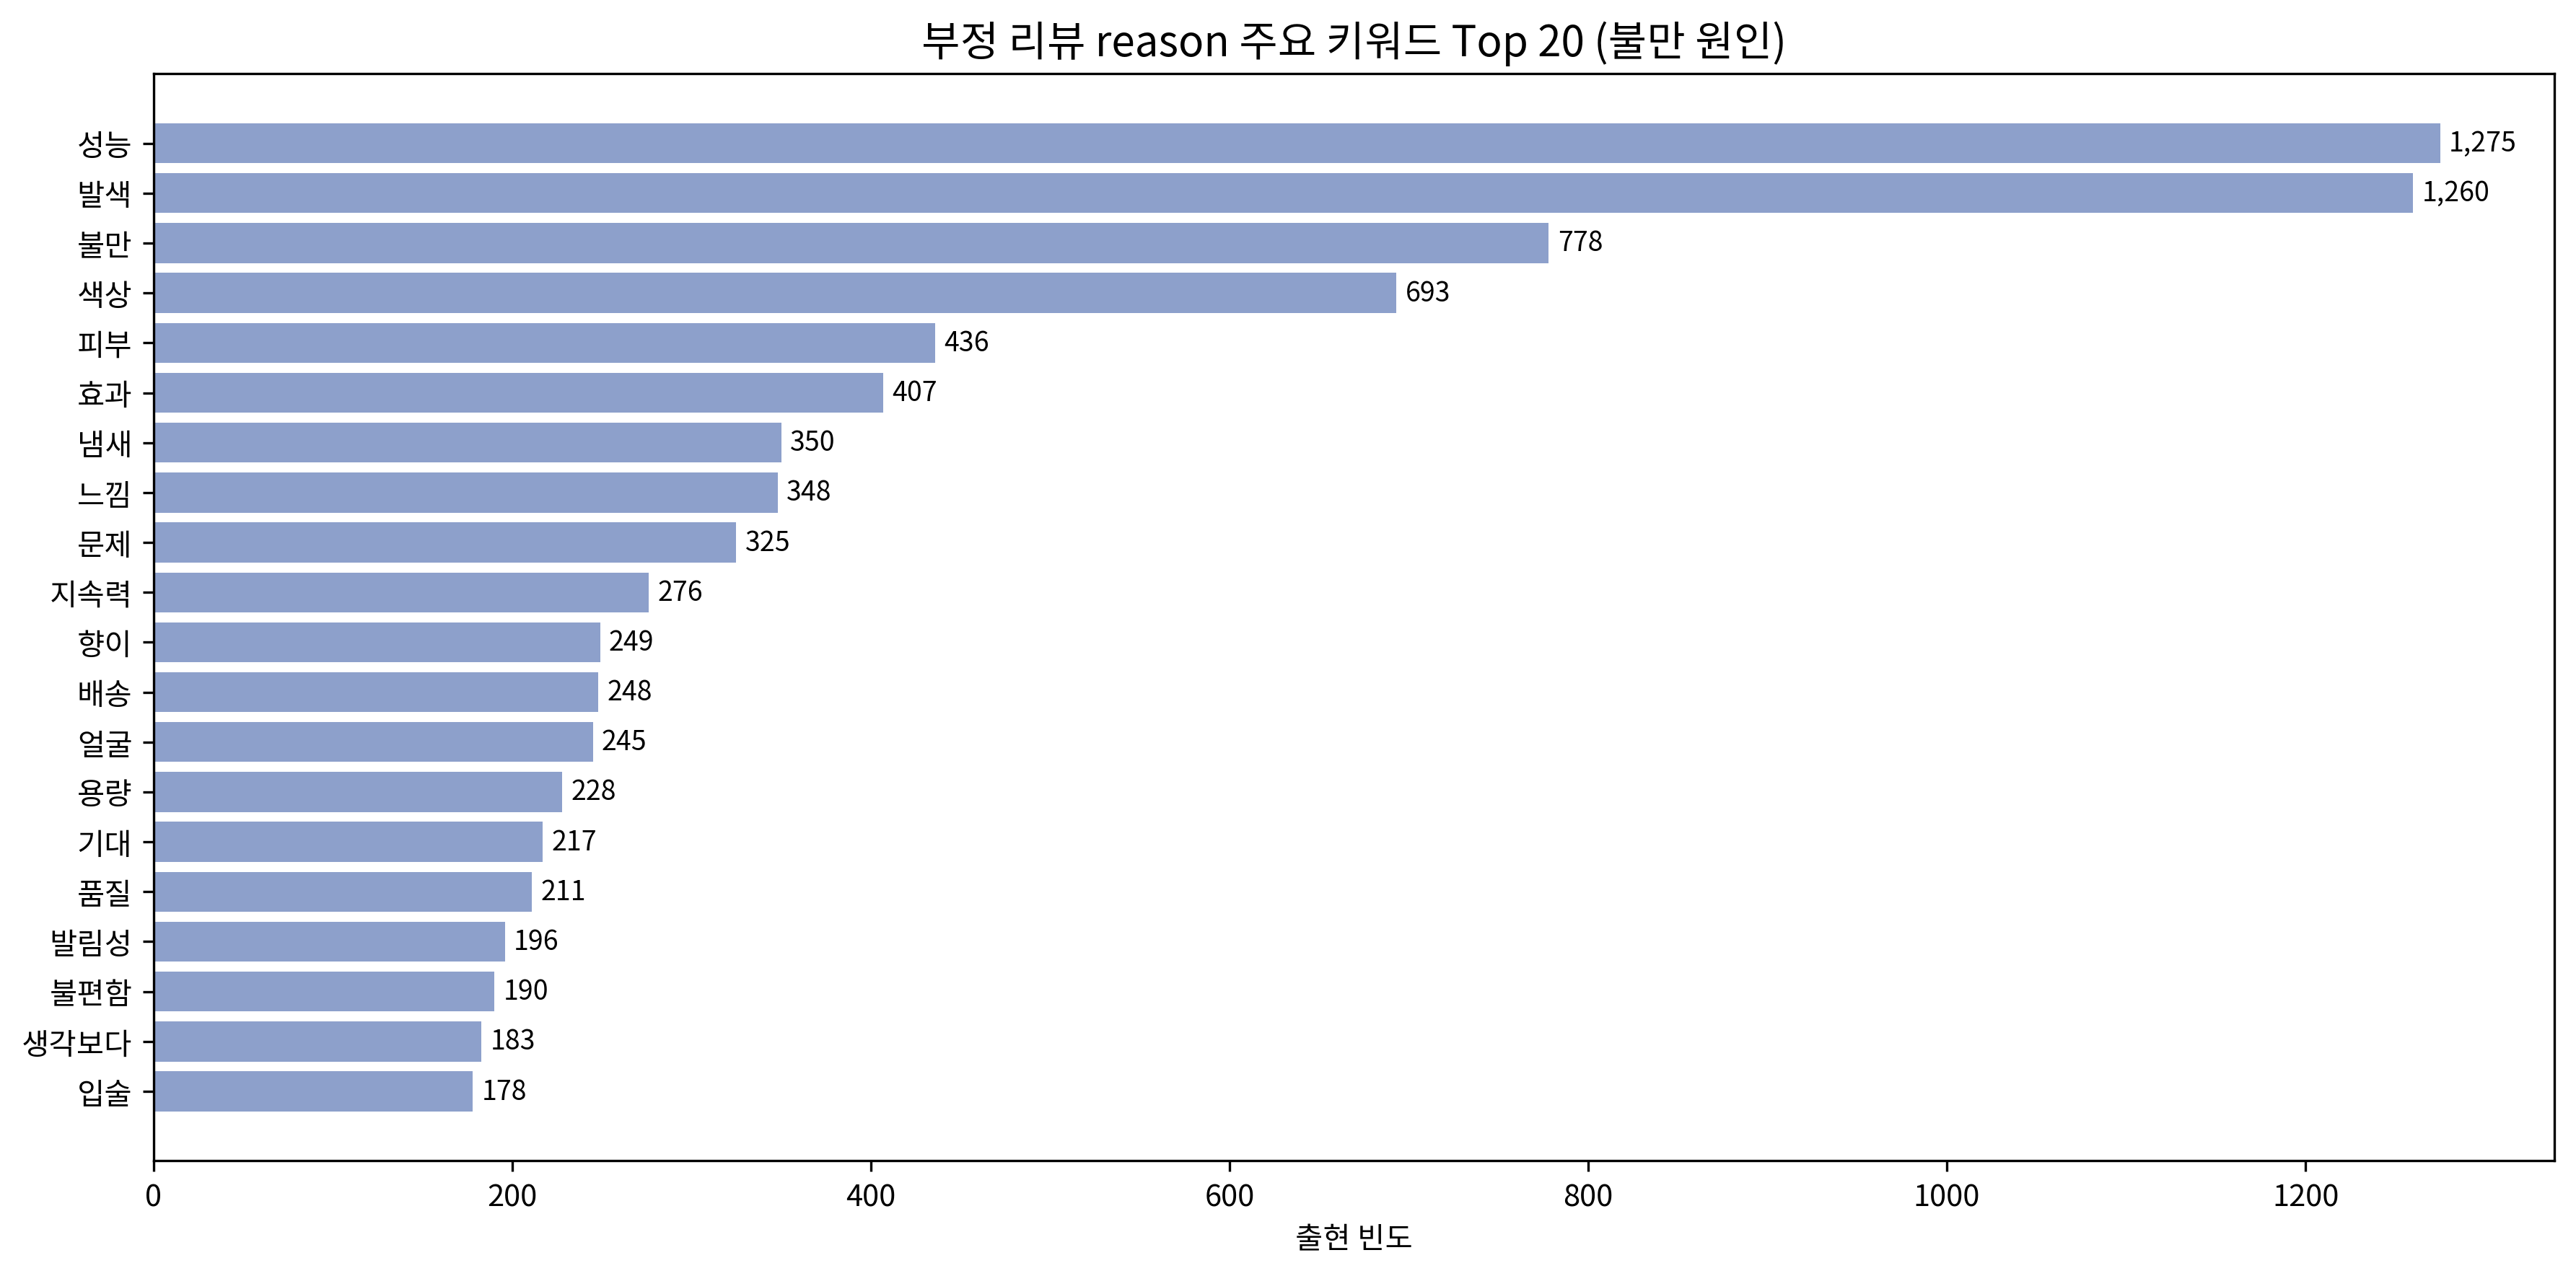

In [ ]:
# 부정 리뷰 reason 키워드 분석
from collections import Counter
import re

neg_reasons = df_negative['reason'].dropna().tolist()

# 불용어 
stop_words = {
    # 조사/어미/접속
    '이다', '하다', '것이', '에서', '으로', '해당', '있다', '없다', '대한', '관련',
    '때문', '이라', '라고', '한다', '있는', '없는', '하는', '된다', '이며', '부분',
    '점에서', '라는', '에는', '이는', '으며', '했다', '이고', '에도', '에게', '까지',
    '않음', '않음을', '있음', '없음', '이라는', '너무', '않다는', '않는', '않다',
    # LLM reason 문체 패턴
    '부정적인', '긍정적인', '중립적인', '부정적', '긍정적', '중립적', '부정적으로',
    '표현', '나타냄', '드러남', '나타내는', '나타나는', '나타냅니다',
    '보이는', '느끼는', '판단', '의미', '좋지', '좋은', '나쁜',
    '감성', '리뷰', '제품', '사용자', '평가', '언급', '내용', '부정', '긍정',
    '사용감', '사용', '명확히', '명확함', '지적', '의견', '언급됨',
}

# 조사 제거: 명사 뒤 조사를 떼어 원형 복원
def strip_particle(word):
    particles = ['에서', '으로', '이라는', '에는', '에도',
                 '이', '가', '을', '를', '의', '에', '와', '과', '도', '은', '는']
    for p in particles:
        if word.endswith(p) and len(word) - len(p) >= 2:
            return word[:-len(p)]
    return word

keywords = []
for reason in neg_reasons:
    words = re.findall(r'[가-힣]{2,}', str(reason))
    for w in words:
        w_clean = strip_particle(w)
        if w_clean not in stop_words and len(w_clean) >= 2:
            keywords.append(w_clean)

keyword_counts = Counter(keywords).most_common(20)

fig, ax = plt.subplots(figsize=(12, 6))
words_list = [w for w, c in keyword_counts[::-1]]
counts_list = [c for w, c in keyword_counts[::-1]]
ax.barh(words_list, counts_list, color='#8da0cb')
ax.set_title('부정 리뷰 reason 주요 키워드 Top 20 (불만 원인)', fontsize=14)
ax.set_xlabel('출현 빈도')
for i, (w, c) in enumerate(keyword_counts[::-1]):
    ax.text(c + 5, i, f'{c:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

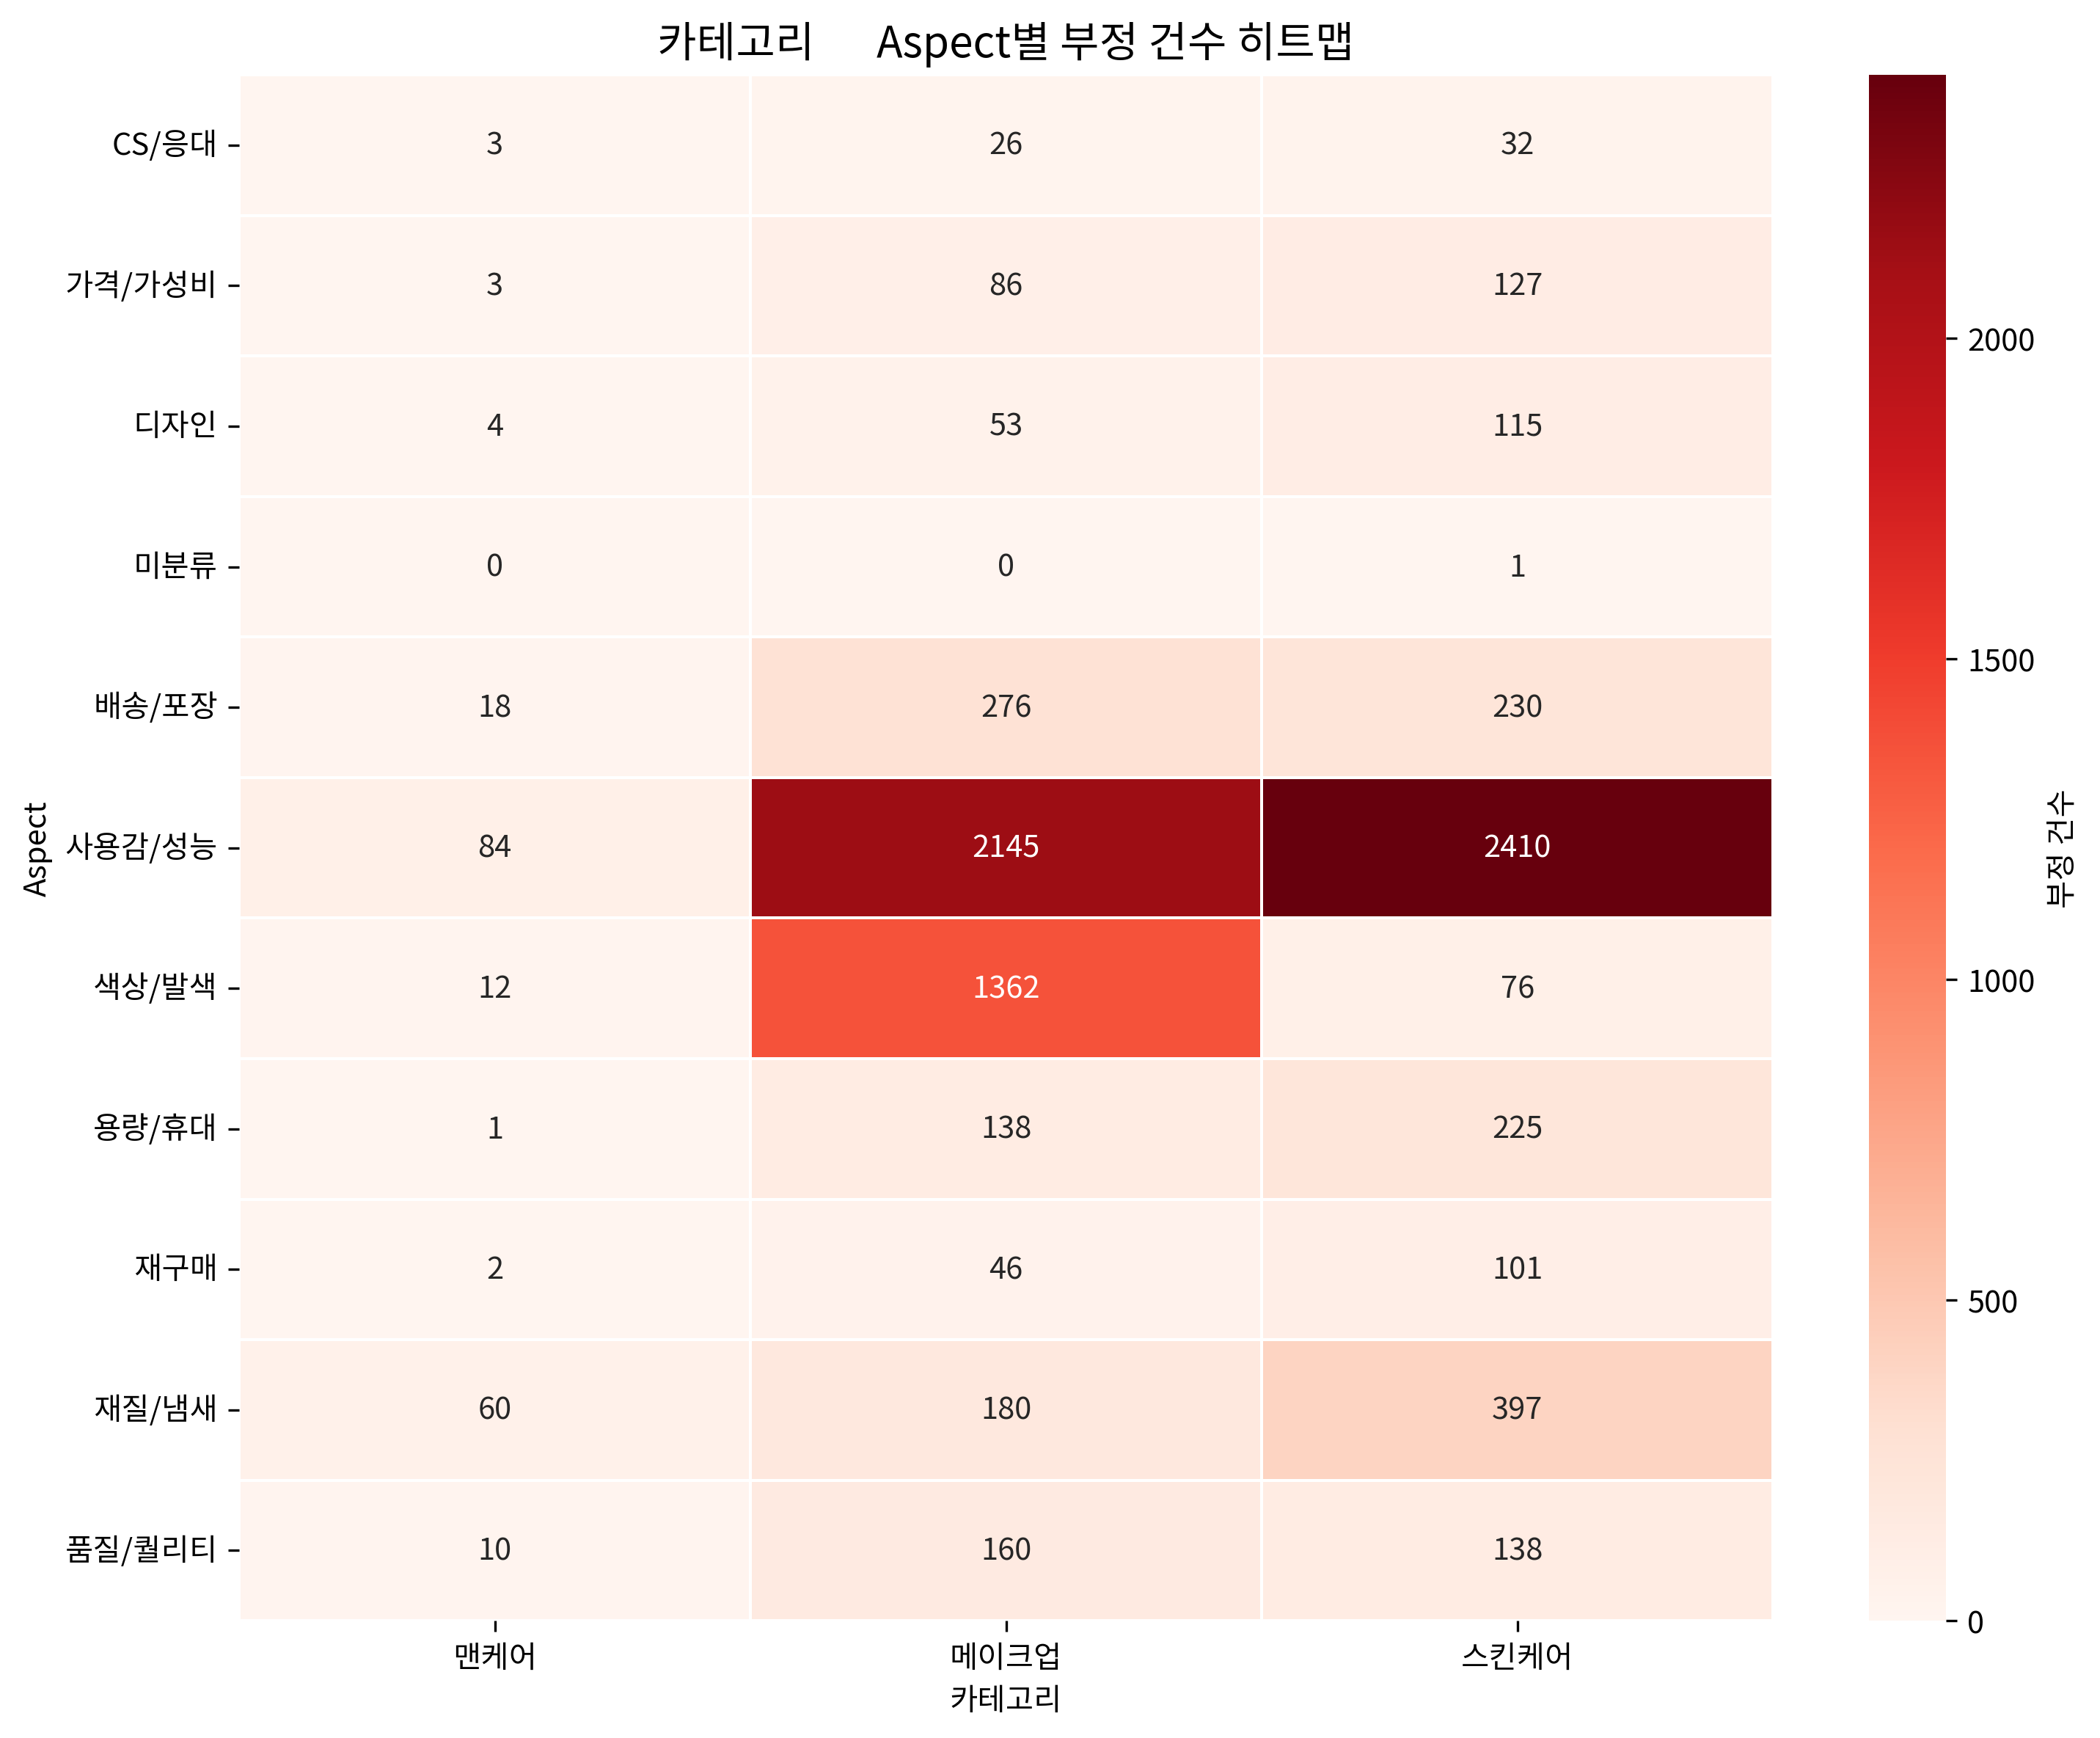

In [81]:
# 카테고리 × Aspect별 부정 히트맵
df_neg_cat = df_negative.dropna(subset=['category_1'])
neg_cross = pd.crosstab(df_neg_cat['aspect'], df_neg_cat['category_1'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(neg_cross, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': '부정 건수'})
ax.set_title('카테고리 × Aspect별 부정 건수 히트맵', fontsize=14)
ax.set_ylabel('Aspect')
ax.set_xlabel('카테고리')
plt.tight_layout()
plt.show()

## 9. 상품별 Sentiment 순위

In [82]:
# 리뷰 10건 이상 상품 필터링
product_counts = df.groupby('product_code').size()
valid_products = product_counts[product_counts >= 10].index
df_valid = df[df['product_code'].isin(valid_products)].copy()

print(f"리뷰 10건 이상 상품: {len(valid_products):,}개 (전체 {n_products:,}개 중)")
print(f"해당 상품 데이터: {len(df_valid):,}행")

리뷰 10건 이상 상품: 594개 (전체 834개 중)
해당 상품 데이터: 25,070행


In [83]:
# 긍정률 / 부정률 계산
product_sent = df_valid.groupby(['product_code', 'name']).apply(
    lambda x: pd.Series({
        '긍정률': (x['aspect_sentiment'] == 'positive').mean() * 100,
        '부정률': (x['aspect_sentiment'] == 'negative').mean() * 100,
        '건수': len(x)
    })
).reset_index()

# 긍정률 Top 10
top10_pos = product_sent.nlargest(10, '긍정률')
print("긍정률 Top 10 상품:")
print("=" * 80)
for _, r in top10_pos.iterrows():
    print(f"  {r['name'][:30]:<32} 긍정률: {r['긍정률']:.1f}%  (건수: {int(r['건수'])})")

print()

# 부정률 Top 10 (Bottom 10)
top10_neg = product_sent.nlargest(10, '부정률')
print("부정률 Top 10 상품 (리스크 상품):")
print("=" * 80)
for _, r in top10_neg.iterrows():
    print(f"  {r['name'][:30]:<32} 부정률: {r['부정률']:.1f}%  (건수: {int(r['건수'])})")

긍정률 Top 10 상품:
  더랩바이블랑두 클리어히알옴므 선크림 35 ml        긍정률: 92.3%  (건수: 13)
  어퓨 더퓨어 티트리 에센스 50ml              긍정률: 90.0%  (건수: 10)
  더랩바이블랑두 클리어히알옴므 올인원에멀전 120 ml    긍정률: 85.7%  (건수: 21)
  트윙클팝 블러 머드 팟(01 핑크테이프) by CLIO   긍정률: 84.6%  (건수: 13)
  [04 어텀퍼지] 머지 렛츠웨어링 아이섀도우         긍정률: 84.6%  (건수: 13)
  더랩바이블랑두 클리어히알옴므 클렌징폼 120 ml      긍정률: 84.2%  (건수: 19)
  쉬크 쉐이브 가드 210g 워시앤쉐이브 폼          긍정률: 81.5%  (건수: 27)
  머지 렛츠 픽싱 젤 아이라이너 더치브라운           긍정률: 81.2%  (건수: 16)
  바세린 인텐시브 케어 립에센스 어드밴스드 10ml      긍정률: 80.0%  (건수: 20)
  [01 애플딥핑] 본셉 글레이즈 딥핑 틴트          긍정률: 80.0%  (건수: 15)

부정률 Top 10 상품 (리스크 상품):
  하드 우드 아이브로우 펜슬 내추럴브라운            부정률: 83.3%  (건수: 12)
  [104 드라이로즈]코시에로 아이콘 컬러완드         부정률: 83.3%  (건수: 12)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 듀이골드   부정률: 82.9%  (건수: 35)
  태그 벨벳블러밤(4호_하티핑크)                부정률: 81.8%  (건수: 11)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 페어리핑   부정률: 78.7%  (건수: 61)
  태그 톤업선파우더(1호_페일라이트) 5 g          부정률: 77.3%  (건수: 22)
  [02 쿨러 댄 미] 플레이 101 바이 에뛰드 멀티    부정률: 76.5%  (건수: 17)
  머지 렛츠 

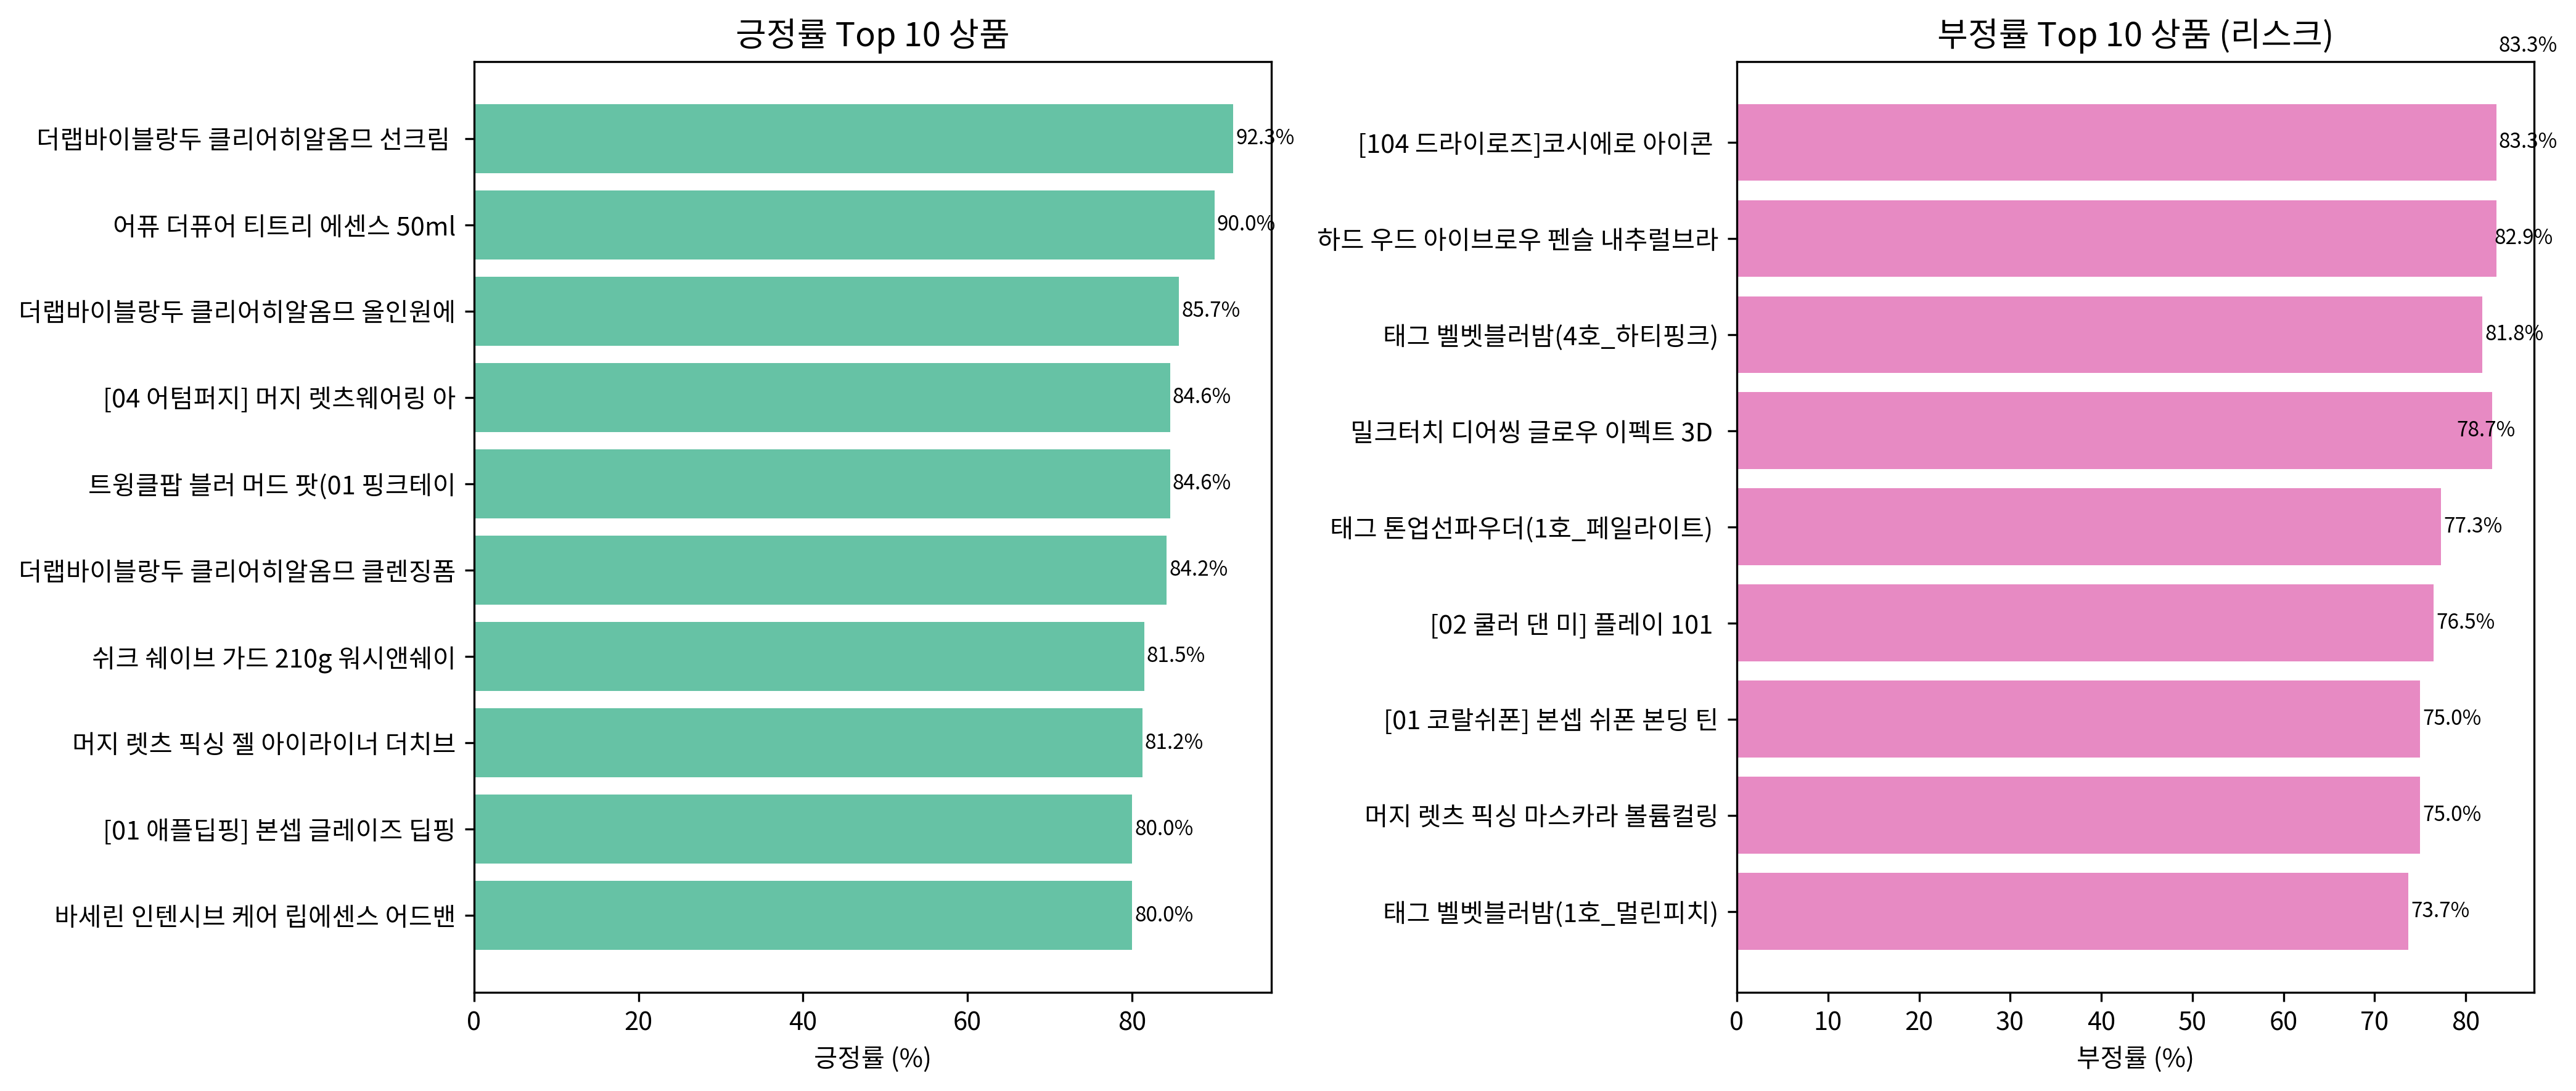

In [84]:
# 시각화: Top 10 / Bottom 10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 긍정률 Top 10
top10_pos_sorted = top10_pos.sort_values('긍정률', ascending=True)
labels_pos = [n[:20] for n in top10_pos_sorted['name']]
axes[0].barh(labels_pos, top10_pos_sorted['긍정률'], color='#66c2a5')
axes[0].set_title('긍정률 Top 10 상품', fontsize=13)
axes[0].set_xlabel('긍정률 (%)')
for i, v in enumerate(top10_pos_sorted['긍정률']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

# 부정률 Top 10
top10_neg_sorted = top10_neg.sort_values('부정률', ascending=True)
labels_neg = [n[:20] for n in top10_neg_sorted['name']]
axes[1].barh(labels_neg, top10_neg_sorted['부정률'], color='#e78ac3')
axes[1].set_title('부정률 Top 10 상품 (리스크)', fontsize=13)
axes[1].set_xlabel('부정률 (%)')
for i, v in enumerate(top10_neg_sorted['부정률']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [85]:
# 부정률 높은 상품의 주요 불만 Aspect
risk_products = top10_neg['product_code'].tolist()
df_risk = df_valid[(df_valid['product_code'].isin(risk_products)) & (df_valid['aspect_sentiment'] == 'negative')]

risk_aspect = df_risk.groupby(['name', 'aspect']).size().reset_index(name='count')
risk_top = risk_aspect.sort_values(['name', 'count'], ascending=[True, False]).groupby('name').head(3)

print("부정률 Top 10 상품의 주요 불만 Aspect:")
print("=" * 80)
for name in risk_top['name'].unique():
    subset = risk_top[risk_top['name'] == name]
    aspects = ', '.join([f"{r['aspect']}({r['count']})" for _, r in subset.iterrows()])
    print(f"  {name[:35]}")
    print(f"    → {aspects}")

부정률 Top 10 상품의 주요 불만 Aspect:
  [01 코랄쉬폰] 본셉 쉬폰 본딩 틴트
    → 색상/발색(5), 사용감/성능(4)
  [02 쿨러 댄 미] 플레이 101 바이 에뛰드 멀티 블렌딩 피
    → 색상/발색(5), 사용감/성능(3), 용량/휴대(3)
  [104 드라이로즈]코시에로 아이콘 컬러완드
    → 색상/발색(5), 사용감/성능(4), 용량/휴대(1)
  머지 렛츠 픽싱 마스카라 볼륨컬링
    → 사용감/성능(8), 품질/퀄리티(1)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 듀이골드
    → 배송/포장(20), 품질/퀄리티(6), 가격/가성비(1)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 페어리핑크
    → 배송/포장(28), 품질/퀄리티(11), CS/응대(6)
  태그 벨벳블러밤(1호_멀린피치)
    → 사용감/성능(8), 색상/발색(3), 재질/냄새(3)
  태그 벨벳블러밤(4호_하티핑크)
    → 사용감/성능(6), 색상/발색(3)
  태그 톤업선파우더(1호_페일라이트) 5 g
    → 사용감/성능(8), 색상/발색(4), 디자인(3)
  하드 우드 아이브로우 펜슬 내추럴브라운
    → 색상/발색(8), 사용감/성능(2)
